# T5-small: inferencia texto a texto y análisis del mecanismo de atención

**Curso:** Procesamiento de Datos Secuenciales · Maestría en Inteligencia Artificial y Ciencia de Datos · UAO  
**Integrantes:** Omar Sánchez Jimenez, Santiago Correa Campaña, Jorge Herrera, Wilson Jesus Riveros  
**Modelo:** `google-t5/t5-small`

> Artículo base: C. Raffel *et al.*, "Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer", JMLR, 2020. https://arxiv.org/abs/1910.10683  
> Repositorio original: https://github.com/google-research/text-to-text-transfer-transformer  
> Checkpoint usado: https://huggingface.co/google-t5/t5-small

En este notebook hacemos la inferencia con T5-small, pero no nos quedamos en "meter un texto y ver qué sale". La idea es abrir el modelo y mostrar qué pasa adentro: cómo entra el texto, cómo se arman Q, K y V, cómo se ve la atención en el encoder y en el decoder, y cómo se genera la salida token por token. Al final medimos qué tan bien lo hace con métricas estándar.



## 1. El problema: el lenguaje es una secuencia

En clase vimos que el lenguaje es el sistema con el que expresamos el pensamiento ordenado en oraciones, y que el orden importa. "Leí el libro" y "Leí todo el libro" se diferencian en una sola palabra y ya no dicen lo mismo. Por eso un texto no se puede tratar como una tabla de columnas independientes: cada palabra depende de las que tiene alrededor.

También vimos el ejemplo de *bank* en la parte de análisis semántico: puede ser un banco de dinero o la orilla de un río, y lo que decide el significado es el contexto. Ese es justo el tipo de problema que la atención resuelve bien, y más adelante lo comprobamos con ese mismo ejemplo.

Las dos tareas que trabajamos son de secuencia a secuencia:

| Tarea | Entrada | Salida |
|---|---|---|
| Resumen | un texto largo en inglés | un texto corto en inglés |
| Traducción | una oración en inglés | la misma oración en alemán |

En las dos, la entrada y la salida tienen longitudes distintas. Por eso necesitamos un modelo **encoder-decoder**: el encoder lee toda la entrada y el decoder escribe la salida a su propio ritmo.

## 2. De las RNN y las LSTM al Transformer

Antes de llegar a T5 vale la pena recordar de dónde venimos, porque lo que tiene de nuevo el Transformer se entiende mejor viendo qué problemas tenían los modelos anteriores.

**RNN.** En clase la escribimos así:

$$h(t) = \tanh\big(W_x\,X(t) + W_h\,h(t-1)\big) \qquad\qquad y(t) = \text{softmax}\big(W_y\,h(t) + b\big)$$

Todo lo que la red sabe de la frase hasta el momento $t$ tiene que caber en el vector $h(t)$. Si la frase es larga, lo del principio se va diluyendo, y además el gradiente se desvanece cuando se propaga hacia atrás por tantos pasos.

**LSTM.** Agrega el estado de celda $C$ y tres compuertas (olvido, entrada y salida) que deciden qué se borra, qué se guarda y qué se muestra. Eso alivia bastante el problema de la memoria, pero sigue procesando palabra por palabra: para calcular el paso 50 hay que haber calculado los 49 anteriores, y eso no se puede paralelizar.

**El cuello de botella del seq2seq.** Cuando se usaban RNN o LSTM para traducir, el encoder resumía toda la frase en un solo vector y el decoder tenía que arreglárselas con eso. La atención (Bahdanau *et al.*, 2015) apareció precisamente para que el decoder pudiera mirar todos los estados del encoder y escoger en cada paso cuáles le sirven.

**Transformer.** Vaswani *et al.* (2017) dieron el paso siguiente: si la atención funciona tan bien, se puede quitar la recurrencia por completo. Cada token mira directamente a todos los demás en una sola operación matricial.

| | RNN | LSTM | Transformer (T5) |
|---|---|---|---|
| Memoria | un vector $h(t)$ | $h(t)$ + celda $C(t)$ con compuertas | atención directa a todos los tokens |
| Dependencias largas | se pierden | mejor, pero se degradan | cualquier par de tokens está a un paso |
| Paralelismo al entrenar | no | no | sí |
| Costo según la longitud $n$ | $n$ pasos secuenciales | $n$ pasos secuenciales | tabla de $n \times n$, pero en paralelo |

Esa tabla de $n \times n$ es el precio a pagar, y la retomamos en las limitaciones.

## 3. La idea de T5

El paper de Raffel *et al.* no propone una arquitectura totalmente nueva. Su aporte principal es una forma de trabajar: **todas las tareas de NLP se escriben como texto de entrada y texto de salida**. Para clasificar, el modelo escribe la etiqueta como palabra; para traducir, escribe la traducción; para resumir, escribe el resumen. La tarea se indica con un prefijo:

```
summarize: <texto>                      ->  <resumen>
translate English to German: <texto>    ->  <traducción>
```

Así se usa el mismo modelo, la misma función de pérdida y el mismo proceso de decodificación para todo. El modelo se preentrenó sobre C4 (unos 750 GB de texto web en inglés, limpiado por los autores) con un objetivo de *span corruption*: se tapan pedazos del texto con marcadores como `<extra_id_0>` y el modelo tiene que escribir lo que faltaba. El checkpoint que usamos además se entrenó con una mezcla de tareas supervisadas, entre ellas resumen (CNN/DailyMail) y traducción (WMT), y por eso responde a esos prefijos sin que nosotros lo ajustemos.

**¿Por qué T5-small?** Es la misma arquitectura que las versiones grandes, solo que con menos capas y vectores más pequeños: unos 60 millones de parámetros, contra 220 millones de T5-base y 11 mil millones de la versión más grande. Corre en Colab gratis y en Streamlit Cloud, y para entender cómo funciona por dentro no necesitamos más.

## 4. Preparación del entorno

`sentencepiece` es el tokenizador que usa T5. `datasets`, `rouge_score` y `sacrebleu` los usamos al final para las métricas. Fijamos `transformers` en la versión 4 porque en algunas funciones internas que usamos para analizar la atención (como `compute_bias`) la versión 5 cambió cosas. Si Colab pide reiniciar el entorno después de instalar, se reinicia y se sigue desde la celda de importaciones.

In [1]:
!pip -q install "transformers>=4.45,<5" sentencepiece datasets rouge_score sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 11.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
import os
import time
import random

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo seleccionado: {dispositivo}")

# Carpeta donde guardamos las figuras para el README
os.makedirs("assets", exist_ok=True)

def guardar_figura(nombre):
    '''Guarda la figura actual en assets/ y la muestra.'''
    plt.tight_layout()
    plt.savefig(f"assets/{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()

Dispositivo seleccionado: cuda


## 5. Carga del modelo y de sus pesos preentrenados

`from_pretrained` descarga dos cosas de Hugging Face: el tokenizador (el archivo `spiece.model`) y los pesos (`model.safetensors`, unos 240 MB). No entrenamos nada; usamos los pesos tal como los publicó Google. Con `modelo.eval()` apagamos el dropout, porque solo vamos a hacer inferencia y queremos que la salida sea siempre la misma.

In [3]:
NOMBRE_MODELO = "google-t5/t5-small"

tokenizador = AutoTokenizer.from_pretrained(NOMBRE_MODELO)
modelo = AutoModelForSeq2SeqLM.from_pretrained(NOMBRE_MODELO)
modelo = modelo.to(dispositivo)
modelo.eval()

numero_parametros = sum(parametro.numel() for parametro in modelo.parameters())

print(f"Modelo cargado: {NOMBRE_MODELO}")
print(f"Parámetros totales: {numero_parametros:,}")
print(f"Capas del encoder: {modelo.config.num_layers}")
print(f"Capas del decoder: {modelo.config.num_decoder_layers}")
print(f"Dimensión del modelo: {modelo.config.d_model}")
print(f"Cabezas de atención: {modelo.config.num_heads}")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Modelo cargado: google-t5/t5-small
Parámetros totales: 60,506,624
Capas del encoder: 6
Capas del decoder: 6
Dimensión del modelo: 512
Cabezas de atención: 8


**Qué nos dice esta salida.** El modelo tiene 60.506.624 parámetros, es decir, unos 60 millones como dice el paper para la versión small. Las otras líneas confirman la configuración: 6 bloques en el encoder, 6 en el decoder, vectores de 512 y 8 cabezas de atención. Con esto ya sabemos que cargamos lo que queríamos y no otra variante.

### 5.1 Configuración completa

La configuración trae más valores que los que imprimimos arriba. Los organizamos en una tabla con lo que significa cada uno.

In [4]:
cfg = modelo.config

tabla_config = pd.DataFrame([
    ("d_model", cfg.d_model, "Tamaño del vector que representa cada token"),
    ("num_heads", cfg.num_heads, "Cabezas de atención por capa"),
    ("d_kv", cfg.d_kv, "Tamaño de Q, K y V dentro de cada cabeza"),
    ("d_ff", cfg.d_ff, "Neuronas de la capa oculta de la feed-forward"),
    ("num_layers", cfg.num_layers, "Bloques del encoder"),
    ("num_decoder_layers", cfg.num_decoder_layers, "Bloques del decoder"),
    ("vocab_size", cfg.vocab_size, "Tokens distintos que conoce el modelo"),
    ("relative_attention_num_buckets", cfg.relative_attention_num_buckets, "Cajones de distancia del sesgo de posición relativa"),
    ("relative_attention_max_distance", cfg.relative_attention_max_distance, "Distancia a partir de la cual todo cae en el último cajón"),
    ("feed_forward_proj", cfg.feed_forward_proj, "Activación de la feed-forward"),
    ("dropout_rate", cfg.dropout_rate, "Dropout usado al entrenar (apagado en eval)"),
    ("tie_word_embeddings", cfg.tie_word_embeddings, "La matriz de embeddings se reutiliza en la capa de salida"),
], columns=["Parámetro", "Valor", "Qué significa"])

tabla_config

,Parámetro,Valor,Qué significa
0,d_model,512,Tamaño del vector que representa cada token
1,num_heads,8,Cabezas de atención por capa
2,d_kv,64,"Tamaño de Q, K y V dentro de cada cabeza"
3,d_ff,2048,Neuronas de la capa oculta de la feed-forward
4,num_layers,6,Bloques del encoder
5,num_decoder_layers,6,Bloques del decoder
6,vocab_size,32128,Tokens distintos que conoce el modelo
7,relative_attention_num_buckets,32,Cajones de distancia del sesgo de posición rel...
8,relative_attention_max_distance,128,Distancia a partir de la cual todo cae en el ú...
9,feed_forward_proj,relu,Activación de la feed-forward


**Cómo leer la tabla.**

- `d_model = 512`: cada token se representa con un vector de 512 números durante todo el recorrido. Es la misma idea de la diapositiva de representación vectorial de palabras (cat, kitten, dog con 7 dimensiones), solo que aquí son 512.
- `num_heads = 8` y `d_kv = 64`: la atención se divide en 8 cabezas y cada una trabaja con vectores Q, K, V de 64. Como 8 × 64 = 512, al juntar las cabezas volvemos al tamaño original.
- `d_ff = 2048`: después de la atención, cada token pasa por una red de dos capas que lo expande a 2048 y lo vuelve a comprimir a 512. Es cuatro veces más ancha que el modelo.
- `vocab_size = 32128`: el modelo conoce 32.128 tokens. Al final, para cada posición de salida produce 32.128 puntajes, uno por cada token posible.
- `relative_attention_num_buckets = 32` y `relative_attention_max_distance = 128`: T5 no le suma la posición a los embeddings. En cambio, agrupa la distancia entre dos tokens en 32 "cajones" y aprende un sesgo para cada uno. Desde 128 tokens de distancia en adelante, todo cae en el mismo cajón. Esto lo vemos con gráfica en la sección 8.6.
- `feed_forward_proj = relu`: la feed-forward usa ReLU.
- `tie_word_embeddings = True`: la misma matriz que convierte tokens en vectores a la entrada se usa para convertir vectores en puntajes a la salida.

### 5.2 ¿Dónde están los parámetros?

,Componente,Parámetros,%
0,Embeddings compartidos,16449536,27.2
1,Encoder (6 bloques),18881280,31.2
2,Decoder (6 bloques),25175808,41.6


,Parte del bloque,Parámetros
0,"Atención (W_Q, W_K, W_V, W_O)",1048576
1,RMSNorm antes de la atención,512
2,Feed-forward (512→2048→512),2097152
3,RMSNorm antes de la feed-forward,512


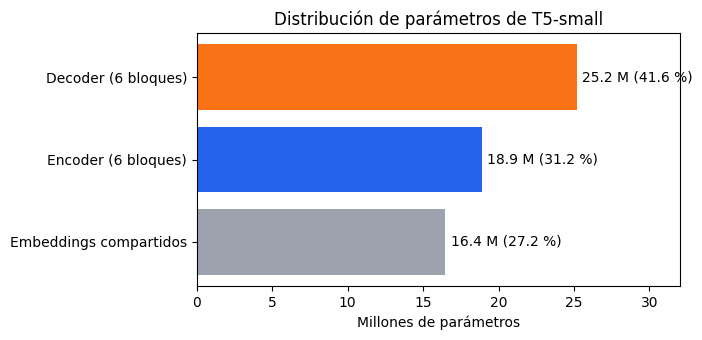

In [5]:
conteo = {"Embeddings compartidos": 0, "Encoder (6 bloques)": 0, "Decoder (6 bloques)": 0}
for nombre, parametro in modelo.named_parameters():
    if nombre.startswith("shared"):
        conteo["Embeddings compartidos"] += parametro.numel()
    elif nombre.startswith("encoder."):
        conteo["Encoder (6 bloques)"] += parametro.numel()
    elif nombre.startswith("decoder."):
        conteo["Decoder (6 bloques)"] += parametro.numel()

tabla_parametros = pd.DataFrame({"Componente": conteo.keys(), "Parámetros": conteo.values()})
tabla_parametros["%"] = (100 * tabla_parametros["Parámetros"] / numero_parametros).round(1)

# Desglose de un bloque del encoder. Usamos el bloque 2 porque el 1
# además guarda el sesgo de posición relativa (256 parámetros extra).
bloque_ejemplo = modelo.encoder.block[1]
desglose_bloque = pd.DataFrame({
    "Parte del bloque": [
        "Atención (W_Q, W_K, W_V, W_O)",
        "RMSNorm antes de la atención",
        "Feed-forward (512→2048→512)",
        "RMSNorm antes de la feed-forward",
    ],
    "Parámetros": [
        sum(p.numel() for p in bloque_ejemplo.layer[0].SelfAttention.parameters()),
        bloque_ejemplo.layer[0].layer_norm.weight.numel(),
        sum(p.numel() for p in bloque_ejemplo.layer[1].DenseReluDense.parameters()),
        bloque_ejemplo.layer[1].layer_norm.weight.numel(),
    ],
})

display(tabla_parametros)
display(desglose_bloque)

fig, ax = plt.subplots(figsize=(7, 3.5))
barras = ax.barh(tabla_parametros["Componente"], tabla_parametros["Parámetros"] / 1e6,
                 color=["#9ca3af", "#2563eb", "#f97316"])
ax.bar_label(barras, labels=[f"{v / 1e6:.1f} M ({p} %)" for v, p in
                             zip(tabla_parametros["Parámetros"], tabla_parametros["%"])], padding=4)
ax.set_xlabel("Millones de parámetros")
ax.set_title("Distribución de parámetros de T5-small")
ax.set_xlim(0, 32)
guardar_figura("parametros")

**Qué muestran las tablas y la gráfica.** Los parámetros quedan repartidos así:

| Componente | Parámetros | % |
|---|---:|---:|
| Embeddings compartidos (32.128 × 512) | 16.449.536 | 27,2 % |
| Encoder (6 bloques) | 18.881.280 | 31,2 % |
| Decoder (6 bloques) | 25.175.808 | 41,6 % |

El decoder pesa más porque cada uno de sus bloques tiene una atención adicional, la cruzada, que el encoder no tiene: son 1.048.576 parámetros más por bloque.

La segunda tabla abre un bloque. Una atención completa son cuatro matrices de 512 × 512 ($W_Q, W_K, W_V, W_O$), o sea 1.048.576 parámetros, y la feed-forward son dos matrices (512 × 2048 y 2048 × 512), 2.097.152 parámetros. Nos llamó la atención que en cada bloque la feed-forward tiene el doble de parámetros que la atención, aunque sea la atención la que se lleva todo el protagonismo.

Las cuentas dan tan redondas porque las capas lineales de T5 no tienen bias, solo matrices de pesos, y cada RMSNorm tiene apenas un vector de 512.

### 5.3 Textos de prueba

Dejamos aquí todos los textos que usamos en el notebook para no repetirlos. Son tres textos para resumir (de distinto tamaño, para ver cómo cambia el tiempo), dos frases para traducir y un texto en español que usamos para mostrar una limitación del modelo.

In [6]:
texto_resumen_1 = (
    "Artificial intelligence is transforming many industries by automating repetitive "
    "tasks, supporting data-driven decisions, and enabling new products. However, its "
    "responsible adoption requires attention to data quality, privacy, fairness, and human "
    "oversight. Organizations that combine technical capabilities with clear governance "
    "are better prepared to obtain value from these systems while reducing their risks."
)

texto_resumen_2 = (
    "Colombia has historically depended on hydroelectric plants for most of its electricity, "
    "which makes the country vulnerable during long dry seasons such as those caused by El Niño. "
    "In recent years the government has promoted solar and wind projects, especially in La Guajira, "
    "where sunlight and wind are abundant throughout the year. Several solar parks have already "
    "started operating and new auctions have attracted foreign investment. However, the expansion "
    "has faced delays because of slow environmental licensing, the need to consult indigenous "
    "communities, and the lack of transmission lines to carry the energy to the main cities. "
    "Experts say that solving these problems is key if the country wants to reduce its dependence "
    "on rain and meet its climate goals."
)

texto_resumen_3 = (
    "The city council approved on Tuesday a plan to expand the public bicycle system, adding 3,000 "
    "new bicycles and 150 stations over the next two years. The project, which will cost around 12 "
    "million dollars, aims to reduce traffic congestion and air pollution in the downtown area, where "
    "average travel times have increased by almost 20 percent since 2019. According to the mobility "
    "department, the current system already registers more than 40,000 trips per day, and surveys show "
    "that most users combine the bicycles with buses or the metro. The new stations will be located "
    "mainly in residential neighborhoods in the south and west of the city, which until now had little "
    "access to the service. Officials also announced that 30 percent of the new bicycles will be "
    "electric, in order to help users who live in hilly areas. Some business owners criticized the "
    "decision to remove parking spaces to build bike lanes, arguing that it could affect their sales. "
    "The council responded that previous studies in other cities found that cyclists tend to visit "
    "local shops more frequently than drivers. The first phase of the expansion is expected to begin "
    "in March, and the administration promised to publish monthly reports on the number of trips, "
    "accidents and user satisfaction."
)

frase_en_1 = "Artificial intelligence can support better decisions."
frase_en_2 = "The students presented their final project about transformers on Thursday."

texto_es = (
    "La inteligencia artificial está transformando muchas industrias al automatizar tareas "
    "repetitivas y apoyar decisiones basadas en datos. Sin embargo, su adopción responsable "
    "requiere prestar atención a la calidad de los datos, la privacidad y la supervisión humana."
)

## 6. Del texto a los vectores: tokenización, índices y embeddings

En clase vimos el flujo del libro de Chollet: **texto → estandarización → tokens → índices → vectores**. T5 lo sigue casi igual, con dos diferencias. La estandarización es mínima: no pasa todo a minúsculas ni quita la puntuación, para no perder información como los nombres propios. Y no parte por palabras sino por **subpalabras**, usando SentencePiece.

Usamos la frase del banco y el río porque la vamos a reutilizar en la parte de atención.

In [7]:
frase_banco = "The bank of the river was full of fish."

ids_banco = tokenizador(frase_banco)["input_ids"]
tokens_banco = tokenizador.convert_ids_to_tokens(ids_banco)

pd.DataFrame({"posición": range(len(ids_banco)), "token": tokens_banco, "id en el vocabulario": ids_banco})

,posición,token,id en el vocabulario
0,0,▁The,37
1,1,▁bank,2137
2,2,▁of,13
3,3,▁the,8
4,4,▁river,4033
5,5,▁was,47
6,6,▁full,423
7,7,▁of,13
8,8,▁fish,2495
9,9,.,5


**Cómo leer la tabla.** Cada fila es un token, con su posición en la secuencia y su índice (id) en el vocabulario.

- El símbolo `▁` (que no es un guion bajo normal) marca que el token empieza una palabra nueva, es decir, que antes había un espacio. Gracias a eso se puede reconstruir el texto original sin ambigüedad.
- El punto queda como un token aparte, igual que en el ejemplo de spaCy de la clase.
- Al final aparece `</s>` con id 1. Es el token de fin de secuencia y el tokenizador lo agrega solo. Le dice al encoder dónde termina la entrada, y en el decoder es el token que indica que ya terminó de generar.
- Hay otro token especial que no aparece aquí: `<pad>`, con id 0. Sirve para rellenar secuencias y además el decoder lo usa como punto de partida para generar.

El id es simplemente el número de fila que se busca en la matriz de embeddings para obtener el vector del token.

In [8]:
frase_ingles = "Sequential data processing with transformers"
frase_espanol = "Procesamiento de datos secuenciales con transformers"

for etiqueta, frase in [("Inglés", frase_ingles), ("Español", frase_espanol)]:
    piezas = tokenizador.tokenize(frase)
    print(f"{etiqueta} ({len(frase.split())} palabras -> {len(piezas)} tokens)")
    print("   ", piezas, "\n")

Inglés (5 palabras -> 7 tokens)
    ['▁Sequ', 'ential', '▁data', '▁processing', '▁with', '▁transformer', 's'] 

Español (6 palabras -> 18 tokens)
    ['▁Pro', 'ces', 'ami', 'en', 'to', '▁de', '▁dat', 'o', 's', '▁se', 'cu', 'en', 'cial', 'e', 's', '▁con', '▁transformer', 's'] 



**Lo que muestra esta comparación.** Las dos frases dicen lo mismo y tienen casi el mismo número de palabras, pero el inglés quedó en 7 tokens y el español en 18. Y no son pedazos con sentido: *Procesamiento* se partió en cinco (`▁Pro`, `ces`, `ami`, `en`, `to`) y hasta *datos* quedó como `▁dat` + `o` + `s`. En inglés, en cambio, casi todas las palabras quedaron completas; solo *Sequential* y *transformers* se partieron. Esto pasa porque el vocabulario de SentencePiece se construyó principalmente con texto en inglés (más algo de alemán, francés y rumano, que eran los idiomas de traducción del paper).

Es lo mismo que mostraba la diapositiva del tokenizador de GPT-4: un token a veces es una palabra completa y a veces solo una parte. Para nosotros tiene una consecuencia práctica: T5-small trabaja mucho mejor en inglés, y por eso las pruebas de resumen las hicimos en inglés.

### 6.1 Los embeddings: la representación vectorial de las palabras

Cada id se convierte en un vector de 512 buscando su fila en la matriz de embeddings (de 32.128 × 512). Para ver si estos vectores guardan algo de significado, repetimos el experimento de la diapositiva de representación vectorial con las mismas palabras: calculamos la similitud coseno entre ellas. Si una palabra se parte en varias subpalabras, promediamos sus vectores.

    cat -> ['▁cat']
 kitten -> ['▁kitten']
    dog -> ['▁dog']
 houses -> ['▁houses']
    man -> ['▁man']
  woman -> ['▁woman']
   king -> ['▁', 'king']
  queen -> ['▁queen']


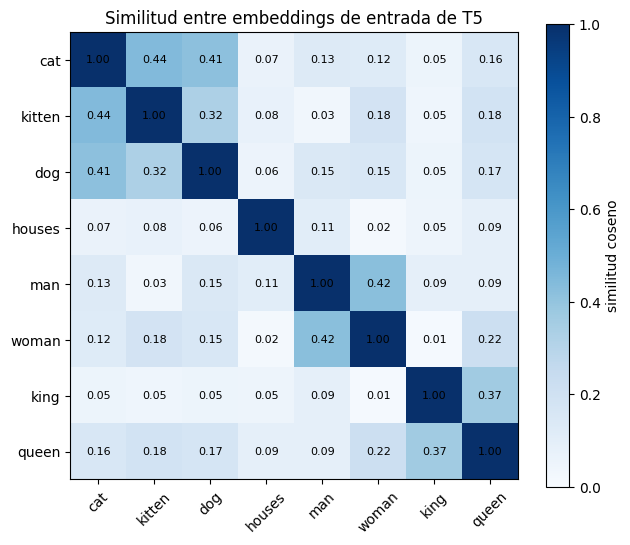

Vecino más cercano de cada palabra:
       cat -> kitten (0.44)
    kitten -> cat (0.44)
       dog -> cat (0.41)
    houses -> man (0.11)
       man -> woman (0.42)
     woman -> man (0.42)
      king -> queen (0.37)
     queen -> king (0.37)

king - man + woman se parece más a (sin contar king, man ni woman):
       queen: 0.315
        girl: 0.306
    princess: 0.274
      prince: 0.098
         dog: 0.045
         boy: 0.016
      houses: -0.040


In [9]:
palabras = ["cat", "kitten", "dog", "houses", "man", "woman", "king", "queen"]
matriz_embeddings = modelo.shared.weight.detach().float().cpu()

def vector_palabra(palabra):
    '''Vector de entrada de una palabra (promedio de sus subpalabras).'''
    ids_palabra = tokenizador(palabra, add_special_tokens=False)["input_ids"]
    return matriz_embeddings[ids_palabra].mean(dim=0)

for p in palabras:
    print(f"{p:>7} -> {tokenizador.tokenize(p)}")

vectores = F.normalize(torch.stack([vector_palabra(p) for p in palabras]), dim=1)
similitud = (vectores @ vectores.T).numpy()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
imagen = ax.imshow(similitud, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(palabras)), palabras, rotation=45)
ax.set_yticks(range(len(palabras)), palabras)
for i in range(len(palabras)):
    for j in range(len(palabras)):
        ax.text(j, i, f"{similitud[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(imagen, ax=ax, label="similitud coseno")
ax.set_title("Similitud entre embeddings de entrada de T5")
guardar_figura("similitud_embeddings")

print("Vecino más cercano de cada palabra:")
for i, p in enumerate(palabras):
    orden = np.argsort(-similitud[i])
    vecino = palabras[orden[1]]
    print(f"   {p:>7} -> {vecino} ({similitud[i, orden[1]]:.2f})")

analogia = F.normalize(vector_palabra("king") - vector_palabra("man") + vector_palabra("woman"), dim=0)
candidatas = ["queen", "princess", "girl", "prince", "boy", "dog", "houses"]
puntajes = {c: float(analogia @ F.normalize(vector_palabra(c), dim=0)) for c in candidatas}
print("\nking - man + woman se parece más a (sin contar king, man ni woman):")
for c, s in sorted(puntajes.items(), key=lambda x: -x[1]):
    print(f"   {c:>9}: {s:.3f}")

**Cómo leer el mapa de calor.** Cada celda es la similitud coseno entre los vectores de dos palabras: 1 significa que apuntan exactamente en la misma dirección y 0 que no tienen relación. La diagonal siempre es 1 porque es cada palabra comparada consigo misma. Abajo del mapa la celda imprime el vecino más cercano de cada palabra y el resultado de la analogía *king − man + woman*.

Aquí hay que tener en cuenta algo importante: estos son los vectores **antes** de pasar por el encoder. Cada palabra tiene un solo vector, sin importar la frase en que aparezca, así que todavía no hay contexto. Por eso las similitudes suelen salir más bajas y menos ordenadas que en el dibujo de la clase, donde los ejes eran interpretables a propósito (*living being, feline, royalty*...). En T5 ninguna de las 512 dimensiones significa algo por sí sola; lo que importa es la dirección del vector completo. Además, T5 no se entrenó para que la analogía funcione (eso era un objetivo de modelos como word2vec), así que el resultado nos dice qué tanto de esa estructura aparece "de rebote".

**Lo que salió en nuestra corrida.** Las similitudes están entre 0,1 y 0,44, bastante más bajas que en el dibujo de la clase, pero la estructura sí aparece: el vecino más cercano de *cat* es *kitten* (0,44), el de *dog* es *cat* (0,41), *man* y *woman* son mutuamente los más cercanos (0,42) y lo mismo *king* y *queen* (0,37). *Houses*, que no tiene nada que ver con las demás, queda prácticamente sola: su vecino más cercano apenas llega a 0,11. Es justo el patrón de la diapositiva, donde *houses* quedaba lejos del grupo de animales.

La analogía *king − man + woman* dio como más parecida a *queen* (0,315), aunque muy de cerca le sigue *girl* (0,306). O sea, el vector resultante sí se movió hacia lo "femenino", pero no quedó tan limpio en la dimensión de "realeza" como en word2vec. Un detalle curioso: *king* no está en el vocabulario como una sola pieza y se partió en `▁` + `king`, así que su vector es el promedio de dos embeddings, y eso también le resta precisión.

Lo interesante viene en la sección 8.5, donde vemos cómo la atención sí cambia el vector de una palabra según la frase en que está.

## 7. Arquitectura detallada

Este es el recorrido completo de una inferencia. $n$ es el número de tokens de entrada y $m$ el de salida.

```
ENTRADA "summarize: ..."  ->  ids (1, n)
   │  embedding compartido (32128 × 512)
   ▼
ENCODER  ×6 bloques. Cada bloque:
   ├─ RMSNorm → autoatención bidireccional (8 cabezas + sesgo relativo) → suma residual
   └─ RMSNorm → feed-forward 512→2048→512 (ReLU)                         → suma residual
   ▼  RMSNorm final  →  "memoria" del encoder (1, n, 512)
                                        │  (de aquí salen K y V de la atención cruzada)
DECODER  ×6 bloques. Cada bloque:       │
   ├─ RMSNorm → autoatención ENMASCARADA (solo mira hacia atrás) → residual
   ├─ RMSNorm → atención CRUZADA: Q del decoder, K y V de la memoria ◄──┘ → residual
   └─ RMSNorm → feed-forward 512→2048→512                         → residual
   ▼  RMSNorm final  (1, m, 512)
   ▼  lm_head 512 → 32128  →  softmax  →  siguiente token
```

Comparado con el Transformer original, hay tres cambios de arquitectura que conviene notar desde ya:

1. La normalización va **antes** de cada subcapa y no después (*pre-norm*). Así el camino de la suma residual queda limpio de principio a fin y el entrenamiento es más estable.
2. La normalización es una versión simplificada, RMSNorm: divide cada vector por la raíz del promedio de sus valores al cuadrado y lo multiplica por un peso aprendido. No resta la media ni tiene bias.
3. No hay codificación posicional sumada al embedding. La posición entra dentro de la atención, como un sesgo que depende de la distancia entre tokens.

Imprimimos un bloque del encoder y la atención cruzada de un bloque del decoder para ver estas piezas en el código de PyTorch.

In [10]:
print("=== Bloque 1 del encoder ===")
print(modelo.encoder.block[0])
print("\n=== Atención cruzada del bloque 1 del decoder ===")
print(modelo.decoder.block[0].layer[1])

=== Bloque 1 del encoder ===
T5Block(
  (layer): ModuleList(
    (0): T5LayerSelfAttention(
      (SelfAttention): T5Attention(
        (q): Linear(in_features=512, out_features=512, bias=False)
        (k): Linear(in_features=512, out_features=512, bias=False)
        (v): Linear(in_features=512, out_features=512, bias=False)
        (o): Linear(in_features=512, out_features=512, bias=False)
        (relative_attention_bias): Embedding(32, 8)
      )
      (layer_norm): T5LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): T5LayerFF(
      (DenseReluDense): T5DenseActDense(
        (wi): Linear(in_features=512, out_features=2048, bias=False)
        (wo): Linear(in_features=2048, out_features=512, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
        (act): ReLU()
      )
      (layer_norm): T5LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
)

=== Atención cruzada del bloque 1 del decoder ===
T5LayerCrossAttention(
  (EncDecAtt

**Cómo leer lo que imprime.**

- `T5LayerSelfAttention` contiene `q`, `k`, `v` y `o`: las cuatro matrices $W_Q, W_K, W_V, W_O$, todas `Linear(512 → 512, bias=False)`. El `bias=False` confirma que no hay términos de sesgo.
- `relative_attention_bias: Embedding(32, 8)` es la tabla del sesgo de posición: 32 cajones de distancia × 8 cabezas. Solo existe en el primer bloque; los demás reutilizan el mismo sesgo.
- `T5LayerNorm` es la RMSNorm, y aparece antes de la atención y antes de la feed-forward.
- `T5DenseActDense` es la feed-forward: `wi` de 512 a 2048, ReLU, y `wo` de 2048 a 512.
- En el decoder, `T5LayerCrossAttention` tiene `EncDecAttention` con las mismas cuatro matrices. La diferencia no está en la forma sino en lo que recibe: Q sale del decoder y K, V de la memoria del encoder.

### 7.1 Seguimiento de dimensiones

Para no quedarnos con el diagrama, medimos las formas reales de los tensores con *hooks*: funciones que PyTorch ejecuta automáticamente cada vez que una capa produce su salida. Primero generamos un resumen y después pasamos entrada y salida una sola vez por el modelo, registrando las formas.

In [11]:
entradas_demo = tokenizador("summarize: " + texto_resumen_1, return_tensors="pt").to(dispositivo)
with torch.inference_mode():
    ids_resumen_demo = modelo.generate(**entradas_demo, max_new_tokens=60, num_beams=4)

registro_dimensiones = []

def crear_gancho(nombre):
    def gancho(modulo, entrada, salida):
        tensor = salida[0] if isinstance(salida, tuple) else salida
        registro_dimensiones.append({"etapa": nombre, "forma del tensor": tuple(tensor.shape)})
    return gancho

capas_a_seguir = {
    "Embedding (encoder y después decoder)": modelo.shared,
    "Salida del bloque 1 del encoder": modelo.encoder.block[0],
    "Salida del bloque 6 del encoder": modelo.encoder.block[-1],
    "RMSNorm final del encoder (memoria)": modelo.encoder.final_layer_norm,
    "Salida del bloque 1 del decoder": modelo.decoder.block[0],
    "RMSNorm final del decoder": modelo.decoder.final_layer_norm,
    "lm_head (puntajes sobre el vocabulario)": modelo.lm_head,
}
ganchos = [capa.register_forward_hook(crear_gancho(nombre)) for nombre, capa in capas_a_seguir.items()]

with torch.inference_mode():
    modelo(**entradas_demo, decoder_input_ids=ids_resumen_demo)

for g in ganchos:
    g.remove()

n_entrada = entradas_demo["input_ids"].shape[1]
m_salida = ids_resumen_demo.shape[1]
print(f"n = {n_entrada} tokens de entrada,  m = {m_salida} posiciones en el decoder\n")
pd.DataFrame(registro_dimensiones)

n = 72 tokens de entrada,  m = 33 posiciones en el decoder



,etapa,forma del tensor
0,Embedding (encoder y después decoder),"(1, 72, 512)"
1,Salida del bloque 1 del encoder,"(1, 72, 512)"
2,Salida del bloque 6 del encoder,"(1, 72, 512)"
3,RMSNorm final del encoder (memoria),"(1, 72, 512)"
4,Embedding (encoder y después decoder),"(1, 33, 512)"
5,Salida del bloque 1 del decoder,"(1, 33, 512)"
6,RMSNorm final del decoder,"(1, 33, 512)"
7,lm_head (puntajes sobre el vocabulario),"(1, 33, 32128)"


**Cómo leer la tabla.** Es el mismo recorrido del diagrama, pero con las formas medidas. En este ejemplo el texto con el prefijo `summarize:` quedó en $n = 72$ tokens y el resumen ocupó $m = 33$ posiciones en el decoder.

- La primera fila es el embedding del lado del encoder: `(1, n, 512)`. El 1 es el tamaño del lote (una sola frase), $n$ son los tokens de entrada y 512 la dimensión del modelo.
- Los bloques del encoder conservan esa forma. La atención y la feed-forward cambian el contenido de los vectores, pero no su tamaño, y eso es lo que permite apilar 6 bloques y sumar las conexiones residuales.
- La salida del encoder, después de la RMSNorm final, tiene la misma forma. Esa es la "memoria" que va a consultar el decoder.
- Luego aparece otra vez el embedding, ahora del lado del decoder, con $m$ posiciones (el `<pad>` inicial más los tokens del resumen).
- La última fila, `lm_head`, queda en `(1, 33, 32128)`: pasa de 512 a 32.128, un puntaje por cada token del vocabulario en cada posición. Aplicando softmax a esos puntajes se obtiene la probabilidad del siguiente token, igual que la $y(t) = \text{softmax}(W_y h(t) + b)$ de la RNN que vimos en clase. La diferencia es que aquí el vector que entra al softmax no es un $h(t)$ que arrastra toda la historia, sino el resultado de varias capas de atención.

## 8. El mecanismo de atención y los tensores Q, K y V

### 8.1 La ecuación

En el Transformer original la atención es

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

En T5 cambia un poco:

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(QK^\top + B\right)V$$

- **No se divide por $\sqrt{d_k}$.** Ese factor existe para que los productos punto no crezcan demasiado y el softmax no se sature. T5 lo resuelve desde la inicialización de los pesos de $W_Q$, así que dividir después sería redundante.
- **Se suma $B$, el sesgo de posición relativa.** Es una matriz de $n \times n$ (una por cabeza) que depende únicamente de la distancia entre el token que pregunta y el token consultado.

### 8.2 De dónde salen Q, K y V

Los tres salen de multiplicar los vectores de los tokens por tres matrices aprendidas:

$$Q = X W_Q \qquad K = X W_K \qquad V = X W_V$$

Nosotros lo pensamos así: **Q** es la pregunta que hace cada token ("¿qué necesito saber?"), **K** es la etiqueta que muestra cada token ("esto es lo que tengo") y **V** es el contenido que entrega si lo escogen. El producto $QK^\top$ compara cada pregunta con todas las etiquetas, el softmax convierte esas comparaciones en porcentajes que suman 1, y con esos porcentajes se mezclan los $V$.

Lo que cambia entre los tres tipos de atención de T5 es **de dónde viene $X$**:

| Atención | Dónde está | Q sale de | K y V salen de | Máscara |
|---|---|---|---|---|
| Autoatención | encoder | tokens de entrada | tokens de entrada | ninguna, mira en ambas direcciones |
| Autoatención enmascarada | decoder | tokens ya generados | tokens ya generados | no puede mirar el futuro |
| Atención cruzada | decoder | tokens ya generados | memoria del encoder | ninguna |

Con 8 cabezas, cada vector de 512 se parte en 8 pedazos de 64 y cada cabeza hace su propia atención. Así cada una puede especializarse en un tipo de relación distinto. Al final se concatenan y pasan por $W_O$.

### 8.3 Calculando la atención a mano

Para estar seguros de que entendemos la fórmula, calculamos la autoatención del primer bloque del encoder paso a paso, con las matrices del modelo, y la comparamos con la que devuelve el propio modelo.

In [12]:
entradas_banco = tokenizador(frase_banco, return_tensors="pt").to(dispositivo)
n = entradas_banco["input_ids"].shape[1]

capa_atencion = modelo.encoder.block[0].layer[0]   # RMSNorm + autoatención del bloque 1
atencion = capa_atencion.SelfAttention
cabezas, d_cabeza = atencion.n_heads, atencion.key_value_proj_dim

with torch.inference_mode():
    # Atención que calcula el modelo (para comparar al final)
    salida_encoder = modelo.encoder(**entradas_banco, output_attentions=True)

    # 1. Embeddings y normalización
    X = modelo.shared(entradas_banco["input_ids"])          # (1, n, 512)
    X_norm = capa_atencion.layer_norm(X)                      # RMSNorm

    # 2. Proyecciones lineales: Q = X·W_Q, K = X·W_K, V = X·W_V
    Q = atencion.q(X_norm)
    K = atencion.k(X_norm)
    V = atencion.v(X_norm)

    # 3. Partir en 8 cabezas de 64
    def separar_cabezas(t):
        return t.view(1, n, cabezas, d_cabeza).transpose(1, 2)   # (1, 8, n, 64)
    Qh, Kh, Vh = separar_cabezas(Q), separar_cabezas(K), separar_cabezas(V)

    # 4. Puntajes Q·Kᵀ (sin dividir por raíz de d_k) + sesgo de posición relativa
    puntajes = Qh @ Kh.transpose(-1, -2)                        # (1, 8, n, n)
    sesgo = atencion.compute_bias(n, n, device=X.device)        # (1, 8, n, n)
    pesos = F.softmax((puntajes + sesgo).float(), dim=-1)

    # 5. Mezclar los V con los pesos, juntar cabezas y aplicar W_O
    Z = pesos @ Vh.float()                                      # (1, 8, n, 64)
    salida_atencion = atencion.o(Z.transpose(1, 2).reshape(1, n, cabezas * d_cabeza).to(X.dtype))

tabla_formas = pd.DataFrame([
    ("X (embeddings normalizados)", tuple(X_norm.shape)),
    ("W_Q, W_K, W_V (cada una)", tuple(atencion.q.weight.shape)),
    ("Q, K, V (cada uno)", tuple(Q.shape)),
    ("Q, K, V separados en cabezas", tuple(Qh.shape)),
    ("Puntajes Q·Kᵀ", tuple(puntajes.shape)),
    ("Sesgo relativo B", tuple(sesgo.shape)),
    ("Pesos de atención (softmax)", tuple(pesos.shape)),
    ("Z = pesos·V", tuple(Z.shape)),
    ("Salida después de W_O", tuple(salida_atencion.shape)),
], columns=["Tensor", "Forma"])
display(tabla_formas)

pesos_modelo = salida_encoder.attentions[0].float()
diferencia = (pesos - pesos_modelo).abs().max().item()
print(f"Cada fila de pesos suma 1: {torch.allclose(pesos.sum(-1), torch.ones_like(pesos.sum(-1)), atol=1e-5)}")
print(f"Diferencia máxima entre nuestro cálculo y el del modelo: {diferencia:.2e}")

,Tensor,Forma
0,X (embeddings normalizados),"(1, 11, 512)"
1,"W_Q, W_K, W_V (cada una)","(512, 512)"
2,"Q, K, V (cada uno)","(1, 11, 512)"
3,"Q, K, V separados en cabezas","(1, 8, 11, 64)"
4,Puntajes Q·Kᵀ,"(1, 8, 11, 11)"
5,Sesgo relativo B,"(1, 8, 11, 11)"
6,Pesos de atención (softmax),"(1, 8, 11, 11)"
7,Z = pesos·V,"(1, 8, 11, 64)"
8,Salida después de W_O,"(1, 11, 512)"


Cada fila de pesos suma 1: True
Diferencia máxima entre nuestro cálculo y el del modelo: 0.00e+00


**Cómo leer la tabla de formas.**

- $X$ es `(1, 11, 512)`: los embeddings de los 11 tokens de la frase, ya normalizados con RMSNorm.
- $W_Q$, $W_K$ y $W_V$ son de `(512, 512)`. PyTorch guarda las matrices como (salida, entrada), por eso internamente la multiplicación es $X W^\top$, pero es la misma $Q = XW_Q$ de la teoría.
- $Q$, $K$ y $V$ salen de `(1, n, 512)`. Al separarlos en cabezas quedan `(1, 8, n, 64)`: 8 cabezas, cada una con un vector de 64 por token.
- Los puntajes $QK^\top$ y el sesgo $B$ son `(1, 8, n, n)`: para cada cabeza, una tabla de cada token contra todos los demás. Aquí se ve el costo cuadrático del que hablamos: si la frase tuviera el doble de tokens, esta tabla sería cuatro veces más grande.
- Después del softmax cada fila suma 1 (la celda lo verifica).
- $Z$ = pesos × $V$ vuelve a `(1, 8, n, 64)`. Se juntan las cabezas (8 × 64 = 512) y $W_O$ deja la salida en `(1, n, 512)`, lista para la suma residual.

La última línea es la que más nos importaba: la diferencia máxima entre nuestro cálculo y los pesos que devuelve el modelo salió **exactamente 0**. No es que se parezcan: son idénticos número por número, porque hicimos las mismas operaciones que hace el modelo por dentro. O sea, la atención de T5 es exactamente $\text{softmax}(QK^\top + B)V$, sin el $\sqrt{d_k}$.

### 8.4 Qué mira cada cabeza

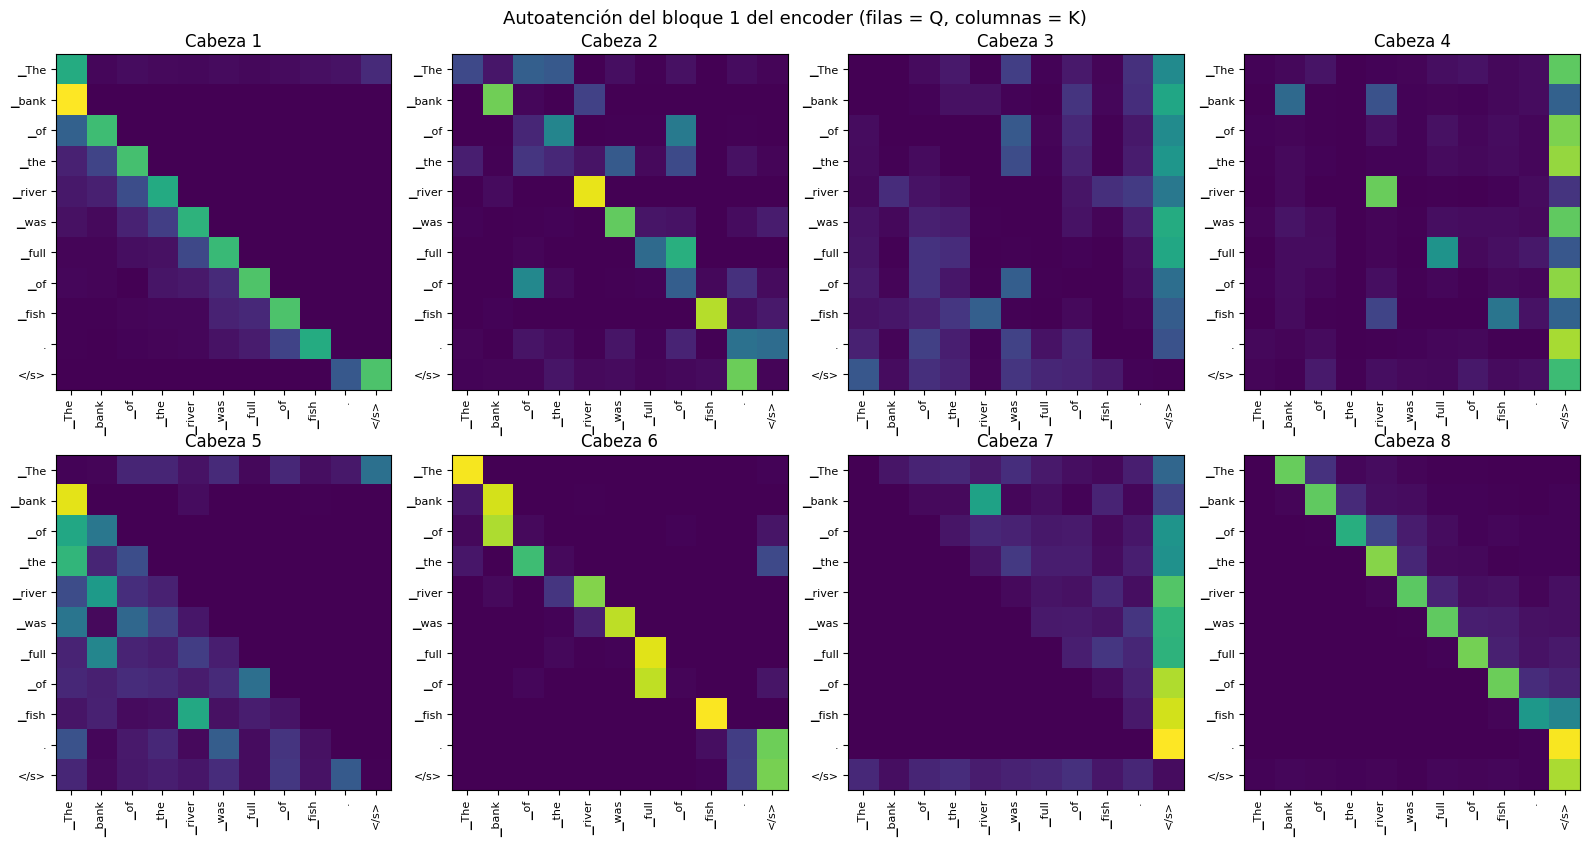

,cabeza,en sí mismo,en el anterior,en el siguiente,en </s>,patrón dominante
0,1,0.122,0.666,0.002,0.076,en el anterior
1,2,0.442,0.095,0.168,0.052,en sí mismo
2,3,0.001,0.012,0.029,0.418,en </s>
3,4,0.248,0.011,0.104,0.599,en </s>
4,5,0.002,0.257,0.001,0.036,en el anterior
5,6,0.602,0.301,0.078,0.175,en sí mismo
6,7,0.003,0.011,0.146,0.583,en </s>
7,8,0.086,0.001,0.756,0.236,en el siguiente


In [13]:
tokens_frase = tokenizador.convert_ids_to_tokens(entradas_banco["input_ids"][0])
pesos_np = pesos[0].cpu().numpy()

fig, ejes = plt.subplots(2, 4, figsize=(16, 8.5))
for cabeza, ax in enumerate(ejes.flat):
    ax.imshow(pesos_np[cabeza], cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"Cabeza {cabeza + 1}")
    ax.set_xticks(range(n), tokens_frase, rotation=90, fontsize=8)
    ax.set_yticks(range(n), tokens_frase, fontsize=8)
fig.suptitle("Autoatención del bloque 1 del encoder (filas = Q, columnas = K)", fontsize=13)
guardar_figura("atencion_cabezas_bloque1")

p = pesos[0].cpu()
resumen_cabezas = pd.DataFrame({
    "cabeza": range(1, cabezas + 1),
    "en sí mismo": p.diagonal(dim1=-2, dim2=-1).mean(-1).numpy(),
    "en el anterior": p.diagonal(offset=-1, dim1=-2, dim2=-1).mean(-1).numpy(),
    "en el siguiente": p.diagonal(offset=1, dim1=-2, dim2=-1).mean(-1).numpy(),
    "en </s>": p[:, :, -1].mean(-1).numpy(),
}).round(3)
patrones = ["en sí mismo", "en el anterior", "en el siguiente", "en </s>"]
resumen_cabezas["patrón dominante"] = resumen_cabezas[patrones].idxmax(axis=1)
resumen_cabezas

**Cómo leer los mapas.** Cada cuadro es una de las 8 cabezas del primer bloque. Las filas son el token que pregunta (Q) y las columnas el token consultado (K); entre más clara la celda, más peso le da. Cada fila suma 1.

La tabla resume cada cabeza con números: el peso promedio que pone en el mismo token, en el anterior, en el siguiente y en `</s>`, y cuál de esos patrones domina.

**Lo que encontramos.** Las cabezas se repartieron el trabajo de una forma muy clara:

| Patrón | Cabezas | Ejemplo |
|---|---|---|
| Mirar al token anterior | 1 y 5 | la cabeza 1 pone en promedio el 67 % del peso en la palabra de la izquierda |
| Mirar al token siguiente | 8 | el 76 % del peso va a la palabra de la derecha |
| Mirarse a sí mismo | 2 y 6 | la cabeza 6 pone el 60 % en el mismo token |
| Mandar el peso a `</s>` | 3, 4 y 7 | alrededor del 40 % al 60 % del peso termina en el token final |

Las cabezas 3, 4 y 7 usan `</s>` como un "lugar neutro": cuando una cabeza no encuentra nada útil en el resto de la frase, descarga ahí la atención en vez de repartirla al azar. La cabeza 3, además, casi nunca se mira a sí misma (0,001), y en la gráfica del sesgo relativo (sección 8.6) se ve por qué: tiene un sesgo muy negativo justo en la distancia 0.

Estos patrones son de posición y no de significado, cosa que tiene sentido en el bloque 1, donde los vectores todavía no tienen contexto y lo que más pesa es el sesgo $B$. Esto también muestra por qué sirve tener varias cabezas: una sola tendría que escoger entre mirar a la izquierda o a la derecha. Con 8, cada una se encarga de algo distinto y después $W_O$ combina todo, algo parecido a como una LSTM combina sus compuertas, pero en paralelo.

### 8.5 El ejemplo del banco: cómo la atención resuelve la ambigüedad

Esta es la parte que más nos gustó, porque conecta directo con la diapositiva de análisis semántico ("What is a bank?").

In [14]:
pos_bank = next(i for i, t in enumerate(tokens_frase) if "bank" in t)
pos_river = next(i for i, t in enumerate(tokens_frase) if "river" in t)

filas = []
for capa, atencion_capa in enumerate(salida_encoder.attentions, start=1):
    fila = atencion_capa[0].mean(0)[pos_bank].float().cpu()   # promedio de las 8 cabezas
    sin_si_mismo = fila.clone()
    sin_si_mismo[pos_bank] = -1
    j = int(sin_si_mismo.argmax())
    filas.append({
        "bloque": capa,
        "token más atendido (sin contar 'bank')": tokens_frase[j],
        "peso": round(float(fila[j]), 3),
        "peso hacia '▁river'": round(float(fila[pos_river]), 3),
    })
display(pd.DataFrame(filas))

def vectores_de_bank(frase):
    '''Devuelve el vector de 'bank' antes y después del encoder.'''
    ent = tokenizador(frase, return_tensors="pt").to(dispositivo)
    toks = tokenizador.convert_ids_to_tokens(ent["input_ids"][0])
    i = next(k for k, t in enumerate(toks) if "bank" in t)
    with torch.inference_mode():
        antes = modelo.shared(ent["input_ids"])[0, i].float().cpu()
        despues = modelo.encoder(**ent).last_hidden_state[0, i].float().cpu()
    return antes, despues

frases_bank = {
    "río": "The bank of the river was full of fish.",
    "dinero 1": "The bank approved my loan application.",
    "dinero 2": "I deposited my salary in the bank.",
}
vectores_bank = {nombre: vectores_de_bank(f) for nombre, f in frases_bank.items()}

def coseno(a, b):
    return float(F.cosine_similarity(a, b, dim=0))

parejas = [("río", "dinero 1"), ("río", "dinero 2"), ("dinero 1", "dinero 2")]
comparacion = pd.DataFrame([{
    "pareja": f"{a} vs {b}",
    "similitud ANTES del encoder": round(coseno(vectores_bank[a][0], vectores_bank[b][0]), 3),
    "similitud DESPUÉS del encoder": round(coseno(vectores_bank[a][1], vectores_bank[b][1]), 3),
} for a, b in parejas])
display(comparacion)

s_rd1 = coseno(vectores_bank["río"][1], vectores_bank["dinero 1"][1])
s_rd2 = coseno(vectores_bank["río"][1], vectores_bank["dinero 2"][1])
s_dd = coseno(vectores_bank["dinero 1"][1], vectores_bank["dinero 2"][1])
if s_dd > max(s_rd1, s_rd2):
    print("Después del encoder, los dos 'bank' de dinero quedaron más parecidos entre sí que con el del río.")
else:
    print("En esta corrida los 'bank' de dinero NO quedaron más cerca entre sí que con el del río.")

,bloque,token más atendido (sin contar 'bank'),peso,peso hacia '▁river'
0,1,▁The,0.252,0.142
1,2,</s>,0.650,0.159
2,3,</s>,0.607,0.092
3,4,</s>,0.545,0.076
4,5,</s>,0.352,0.092
5,6,</s>,0.531,0.017


,pareja,similitud ANTES del encoder,similitud DESPUÉS del encoder
0,río vs dinero 1,1.0,0.458
1,río vs dinero 2,1.0,0.391
2,dinero 1 vs dinero 2,1.0,0.667


Después del encoder, los dos 'bank' de dinero quedaron más parecidos entre sí que con el del río.


**Cómo leer la primera tabla.** Seguimos al token `▁bank` por los 6 bloques del encoder. En cada uno mostramos a qué otro token le pone más atención (promediando las 8 cabezas) y cuánto peso le da a `▁river`, que es la palabra que define su significado en esta frase.

El resultado no fue tan "bonito" como esperábamos, y nos parece importante decirlo. En el bloque 1, *bank* mira sobre todo a *The* (0,25), la palabra de al lado, y le da 0,14 a *river*. Del bloque 2 en adelante el token que más atención recibe es `</s>` (entre 0,35 y 0,65), y el peso hacia *river* va bajando hasta 0,02 en el último bloque. O sea, *bank* nunca le pone la mayor parte de su atención a *river*.

**Cómo leer la segunda tabla.** Comparamos el vector de *bank* en tres frases: una del río y dos de dinero.

- **Antes del encoder** las tres similitudes son 1,0: el vector es idéntico en las tres frases, porque el embedding solo depende del id del token y no sabe en qué frase está.
- **Después del encoder** los dos *bank* de dinero quedaron con una similitud de 0,67 entre sí, mientras que cada uno comparado con el del río quedó en 0,46 y 0,39.

Así que, aunque *bank* no le ponga mucha atención directa a *river*, el contexto sí cambió su representación, y en la dirección correcta: los dos sentidos de dinero quedaron juntos y el del río quedó aparte. Nuestra interpretación es que la información viaja de forma indirecta. Ese 14 % que va a *river* en los primeros bloques ya alcanza a mezclar algo de su significado, y además en cada bloque los demás tokens (incluido `</s>`) ya traen información de toda la frase, así que mirar a `</s>` no es mirar a "nada" sino a un resumen de la oración.

De aquí sacamos dos conclusiones. La primera es la de la diapositiva de historia del NLP: el significado de una palabra no está guardado en un vector fijo sino que se construye con el contexto, que es la semántica léxica que vimos en clase, pero calculada por el modelo. La segunda es una advertencia: el mapa de atención no cuenta toda la historia. Si solo hubiéramos mirado la primera tabla, habríamos concluido que el modelo no usa el contexto, y la segunda tabla muestra que sí lo usa.

### 8.6 El sesgo de posición relativa

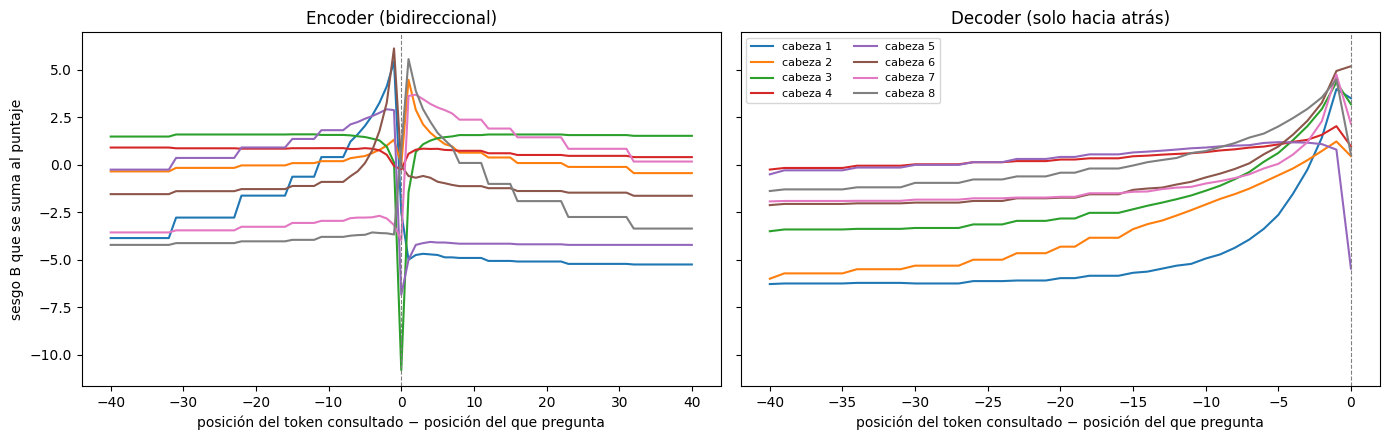

Parámetros del sesgo relativo en el encoder: 256


In [15]:
d = 40
with torch.inference_mode():
    sesgo_enc = modelo.encoder.block[0].layer[0].SelfAttention.compute_bias(
        2 * d + 1, 2 * d + 1, device=dispositivo)[0, :, d, :].float().cpu().numpy()
    sesgo_dec = modelo.decoder.block[0].layer[0].SelfAttention.compute_bias(
        2 * d + 1, 2 * d + 1, device=dispositivo)[0, :, d, :].float().cpu().numpy()
distancias = np.arange(-d, d + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for cabeza in range(cabezas):
    ax1.plot(distancias, sesgo_enc[cabeza], label=f"cabeza {cabeza + 1}")
    ax2.plot(distancias[:d + 1], sesgo_dec[cabeza, :d + 1], label=f"cabeza {cabeza + 1}")
ax1.set_title("Encoder (bidireccional)")
ax2.set_title("Decoder (solo hacia atrás)")
for ax in (ax1, ax2):
    ax.axvline(0, color="gray", lw=0.8, ls="--")
    ax.set_xlabel("posición del token consultado − posición del que pregunta")
ax1.set_ylabel("sesgo B que se suma al puntaje")
ax2.legend(fontsize=8, ncol=2)
guardar_figura("sesgo_relativo")

print("Parámetros del sesgo relativo en el encoder:",
      modelo.encoder.block[0].layer[0].SelfAttention.relative_attention_bias.weight.numel())

**Cómo leer la gráfica.** Cada curva es una cabeza y muestra cuánto se le suma al puntaje de atención según la distancia. El eje x es la posición del token consultado menos la del que pregunta: negativo quiere decir que está a la izquierda y positivo que está a la derecha. Un valor alto significa que la cabeza tiende a mirar a esa distancia aunque el contenido no lo pida.

Cómo funciona por dentro: la distancia se convierte en uno de 32 cajones. En el encoder la mitad de los cajones es para la izquierda y la otra mitad para la derecha. Las distancias cortas tienen cada una su propio cajón, y a partir de ahí los cajones se van haciendo más anchos, de forma logarítmica, hasta 128. Por eso las curvas tienen detalle cerca de cero y se vuelven escalones planos a medida que se alejan. Tiene sentido: importa mucho si una palabra está justo al lado o a tres posiciones, pero da casi igual si está a 30 o a 35.

En el decoder solo graficamos la parte izquierda, porque la máscara impide mirar hacia adelante y el sesgo del lado derecho nunca se usa.

Las curvas coinciden con lo que vimos en los mapas de la sección 8.4. La cabeza 1 (azul) tiene su pico en −1 y valores muy negativos a la derecha: por eso mira al token anterior. La cabeza 8 (gris) tiene el pico en +1: mira al siguiente. La cabeza 3 (verde) cae hasta cerca de −11 justo en 0, y por eso casi nunca se mira a sí misma. En el decoder casi todas las cabezas tienen su máximo en −1 y van bajando hacia la izquierda: le dan más importancia a lo que se acaba de generar, algo parecido a lo que hace una RNN con $h(t-1)$, pero sin perder del todo lo anterior. Y todo esto cuesta muy poco: el sesgo se calcula una vez en el primer bloque y se reutiliza en los seis, con apenas 32 × 8 = 256 parámetros en el encoder (y otros 256 en el decoder).

Comparado con la codificación sinusoidal del Transformer original, esto tiene dos ventajas: el modelo aprende qué distancias le importan, y como no depende de la posición absoluta, en principio se puede aplicar a secuencias más largas que las vistas en el entrenamiento.

## 9. La atención en el decoder: enmascarada y cruzada

Para mirar el decoder usamos la traducción, porque ahí es fácil revisar si la atención tiene sentido: sabemos qué palabra en alemán corresponde a cuál en inglés.

Traducción: Künstliche Intelligenz kann bessere Entscheidungen unterstützen.


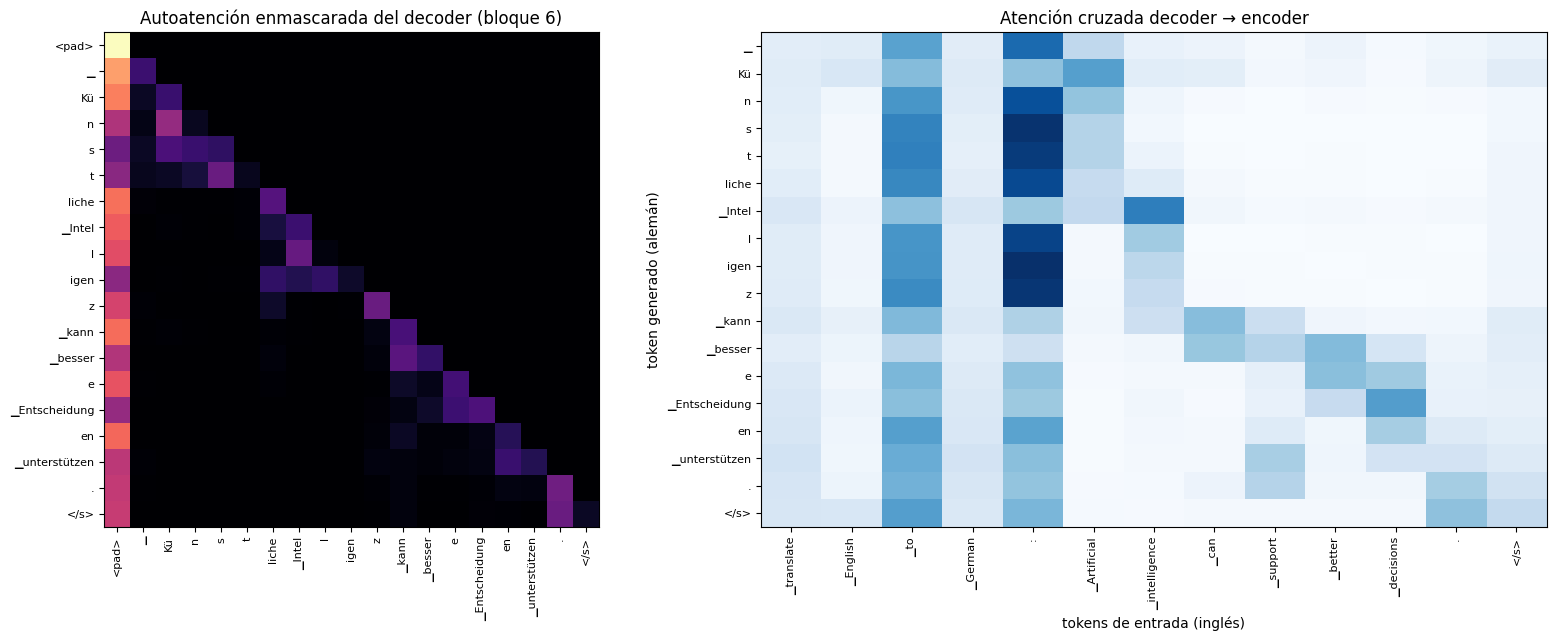

Peso máximo por encima de la diagonal (futuro): 0.00e+00


,token generado,token en inglés más atendido,peso
0,▁,▁Artificial,0.119
1,Kü,▁Artificial,0.249
2,n,▁Artificial,0.177
3,s,▁Artificial,0.135
4,t,▁Artificial,0.136
5,liche,▁Artificial,0.109
6,▁Intel,▁intelligence,0.307
7,l,▁intelligence,0.162
8,igen,▁intelligence,0.124
9,z,▁intelligence,0.110


In [16]:
entradas_tr = tokenizador("translate English to German: " + frase_en_1, return_tensors="pt").to(dispositivo)
with torch.inference_mode():
    ids_tr = modelo.generate(**entradas_tr, max_new_tokens=40, num_beams=4,
                             do_sample=False, early_stopping=True)
    salida_tr = modelo(**entradas_tr, decoder_input_ids=ids_tr, output_attentions=True)

tokens_entrada_tr = tokenizador.convert_ids_to_tokens(entradas_tr["input_ids"][0])
tokens_salida_tr = tokenizador.convert_ids_to_tokens(ids_tr[0])
print("Traducción:", tokenizador.decode(ids_tr[0], skip_special_tokens=True))

# Autoatención enmascarada: último bloque, promedio de cabezas
auto_dec = salida_tr.decoder_attentions[-1][0].mean(0).float().cpu().numpy()

# Atención cruzada: promedio de los 6 bloques y las 8 cabezas.
# La posición i del decoder es la que predice el token i+1, por eso
# quitamos la última fila y etiquetamos con los tokens desde el segundo.
cruzada = torch.stack(salida_tr.cross_attentions).mean(dim=(0, 2))[0].float().cpu().numpy()
cruzada = cruzada[:-1]
etiquetas_generadas = tokens_salida_tr[1:]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5), gridspec_kw={"width_ratios": [1, 1.4]})
ax1.imshow(auto_dec, cmap="magma", vmin=0, vmax=1)
ax1.set_xticks(range(len(tokens_salida_tr)), tokens_salida_tr, rotation=90, fontsize=8)
ax1.set_yticks(range(len(tokens_salida_tr)), tokens_salida_tr, fontsize=8)
ax1.set_title("Autoatención enmascarada del decoder (bloque 6)")

ax2.imshow(cruzada, cmap="Blues", aspect="auto")
ax2.set_xticks(range(len(tokens_entrada_tr)), tokens_entrada_tr, rotation=90, fontsize=8)
ax2.set_yticks(range(len(etiquetas_generadas)), etiquetas_generadas, fontsize=8)
ax2.set_xlabel("tokens de entrada (inglés)")
ax2.set_ylabel("token generado (alemán)")
ax2.set_title("Atención cruzada decoder → encoder")
guardar_figura("atencion_decoder_traduccion")

encima_diagonal = np.triu(auto_dec, k=1).max()
print(f"Peso máximo por encima de la diagonal (futuro): {encima_diagonal:.2e}")

try:
    inicio_frase = tokens_entrada_tr.index(":") + 1
except ValueError:
    inicio_frase = 0
alineacion = []
for i, token in enumerate(etiquetas_generadas):
    if token == "</s>":
        continue
    j = inicio_frase + int(np.argmax(cruzada[i, inicio_frase:]))
    alineacion.append({"token generado": token, "token en inglés más atendido": tokens_entrada_tr[j],
                       "peso": round(float(cruzada[i, j]), 3)})
pd.DataFrame(alineacion)

**Mapa izquierdo, autoatención enmascarada.** Todo lo que está por encima de la diagonal es negro: cuando el decoder está escribiendo la palabra 4 no puede ver la 5, porque todavía no existe. La celda lo comprueba: el peso máximo encima de la diagonal salió exactamente 0. La primera fila tiene todo el peso en `<pad>`, porque es lo único que hay en ese momento.

Se ven dos cosas más. Casi todas las filas ponen bastante peso en la primera columna, `<pad>`, que en el decoder cumple el mismo papel de "lugar neutro" que `</s>` en el encoder. Y justo debajo de la diagonal hay una línea más clara: cada token mira mucho al anterior, por ejemplo `liche` mira a `t` y `igen` mira a `l`, porque esas piezas forman una sola palabra (*Künstliche*, *Intelligenz*).

Es el mismo principio de la RNN de la clase, donde $h(t)$ depende de $h(t-1)$ pero nunca del futuro. La diferencia es que aquí cada token mira directamente a todos los anteriores, en vez de recibirlos comprimidos en un solo vector.

**Mapa derecho, atención cruzada.** Cada fila es un token en alemán que generó el modelo, y las columnas son los tokens de la entrada en inglés, incluido el prefijo. Promediamos los 6 bloques y las 8 cabezas. Aquí Q viene del decoder y K, V vienen de la memoria del encoder: el decoder pregunta "para escribir esta palabra, ¿en qué parte del inglés me fijo?".

Llama la atención que las columnas de `▁to` y `:` (del prefijo) son muy oscuras en casi todas las filas. Igual que con `</s>`, el modelo usa esos tokens como apoyo general. Por eso la tabla de alineación los deja por fuera y busca solo dentro de la frase.

**La tabla de alineación salió perfecta.** Todos los pedazos de *Künstliche* (`Kü`, `n`, `s`, `t`, `liche`) miran a *Artificial*; todos los de *Intelligenz* miran a *intelligence*; *kann* mira a *can*, *besser* a *better*, *Entscheidung* a *decisions* y el punto al punto. El caso que más nos gustó es el verbo: en alemán *unterstützen* queda al final de la frase, mientras que *support* en inglés está en la mitad, y aun así la atención va a buscarlo a donde está. Con el vector único de contexto de los seq2seq con RNN eso era mucho más difícil.

Una advertencia, que ya vimos con *bank*: un peso de atención alto no "explica" por sí solo la decisión del modelo. Muestra a dónde está mirando, pero la salida también depende de las feed-forward y de las conexiones residuales, así que estos mapas hay que leerlos como una pista y no como una prueba.

## 10. Cómo se genera la salida, token por token

`generate()` esconde lo que pasa realmente. Aquí lo hacemos a mano con decodificación voraz (*greedy*), que en cada paso escoge el token más probable. El encoder corre **una sola vez**, y el decoder corre una vez por cada token nuevo, recibiendo todo lo que ha generado hasta ese momento.

,paso,token elegido,probabilidad,siguientes 4 opciones
0,1,▁,0.365,"▁Die (0.24), ▁K (0.13), ▁Kunst (0.04), ▁Ge (0.03)"
1,2,Kü,0.990,"k (0.00), <unk> (0.00), Dabei (0.00), Unsere (..."
2,3,n,1.000,"h (0.00), s (0.00), k (0.00), nes (0.00)"
3,4,s,0.999,"f (0.00), ste (0.00), sti (0.00), sten (0.00)"
4,5,t,0.996,"tige (0.00), tig (0.00), tler (0.00), th (0.00)"
5,6,liche,0.973,"licher (0.02), lich (0.01), lichen (0.00), lic..."
6,7,▁Intel,0.984,"s (0.00), ▁In (0.00), ▁Informationen (0.00), ▁..."
7,8,l,1.000,"le (0.00), igen (0.00), la (0.00), lation (0.00)"
8,9,igen,1.000,"ige (0.00), izi (0.00), i (0.00), igkeit (0.00)"
9,10,z,0.998,"zen (0.00), ze (0.00), zzi (0.00), zi (0.00)"


Traducción greedy: Künstliche Intelligenz kann bessere Entscheidungen unterstützen.
Traducción con beam search (num_beams=4): Künstliche Intelligenz kann bessere Entscheidungen unterstützen.
Log-probabilidad de la secuencia greedy: -1.756
Perplejidad: 1.102


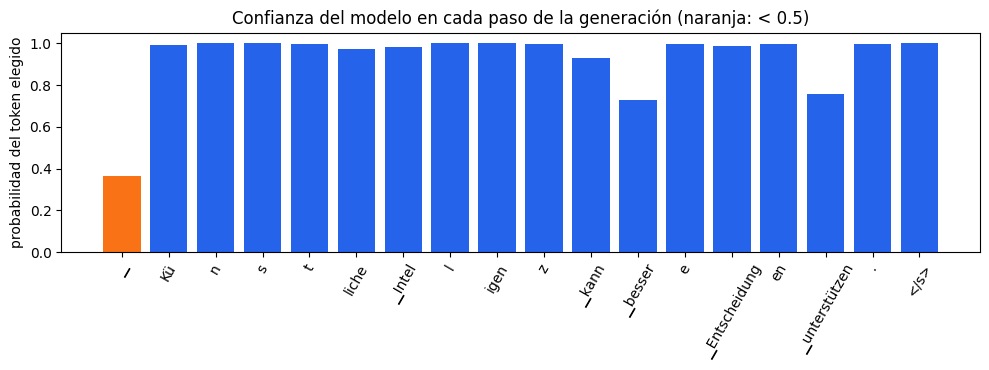

In [17]:
entradas_paso = tokenizador("translate English to German: " + frase_en_1, return_tensors="pt").to(dispositivo)

with torch.inference_mode():
    memoria = modelo.encoder(**entradas_paso).last_hidden_state      # el encoder corre una vez
    ids_decoder = torch.tensor([[modelo.config.decoder_start_token_id]], device=dispositivo)
    pasos, probabilidades_elegidas = [], []
    for paso in range(30):
        logits = modelo(encoder_outputs=(memoria,),
                        attention_mask=entradas_paso["attention_mask"],
                        decoder_input_ids=ids_decoder).logits
        probabilidades = F.softmax(logits[0, -1].float(), dim=-1)    # 32.128 probabilidades
        top = torch.topk(probabilidades, 5)
        elegido = top.indices[0]
        probabilidades_elegidas.append(float(top.values[0]))
        pasos.append({
            "paso": paso + 1,
            "token elegido": tokenizador.convert_ids_to_tokens(int(elegido)),
            "probabilidad": round(float(top.values[0]), 3),
            "siguientes 4 opciones": ", ".join(
                f"{tokenizador.convert_ids_to_tokens(int(i))} ({float(v):.2f})"
                for i, v in zip(top.indices[1:], top.values[1:])),
        })
        ids_decoder = torch.cat([ids_decoder, elegido.view(1, 1)], dim=1)
        if int(elegido) == tokenizador.eos_token_id:
            break

tabla_pasos = pd.DataFrame(pasos)
display(tabla_pasos)

log_prob = float(np.log(probabilidades_elegidas).sum())
print(f"Traducción greedy: {tokenizador.decode(ids_decoder[0], skip_special_tokens=True)}")
print(f"Traducción con beam search (num_beams=4): {tokenizador.decode(ids_tr[0], skip_special_tokens=True)}")
print(f"Log-probabilidad de la secuencia greedy: {log_prob:.3f}")
print(f"Perplejidad: {np.exp(-log_prob / len(tabla_pasos)):.3f}")

fig, ax = plt.subplots(figsize=(10, 3.8))
colores = ["#2563eb" if p >= 0.5 else "#f97316" for p in tabla_pasos["probabilidad"]]
ax.bar(range(len(tabla_pasos)), tabla_pasos["probabilidad"], color=colores)
ax.set_xticks(range(len(tabla_pasos)), tabla_pasos["token elegido"], rotation=60)
ax.set_ylim(0, 1.05)
ax.set_ylabel("probabilidad del token elegido")
ax.set_title("Confianza del modelo en cada paso de la generación (naranja: < 0.5)")
guardar_figura("generacion_paso_a_paso")

**Cómo leer la tabla y la gráfica.** En cada paso el decoder produce 32.128 puntajes, el softmax los convierte en probabilidades y escogemos la más alta. La tabla muestra el token elegido, su probabilidad y las cuatro opciones que le siguieron. La gráfica muestra esa probabilidad paso a paso: en azul los pasos donde el modelo estaba seguro (más de 0,5) y en naranja donde dudó.

**Lo que salió.** La traducción tomó 18 pasos y el modelo estuvo seguro en casi todos. Los pasos interesantes son tres:

- **Paso 1** (`▁`, 0,37): es el único naranja. Es la decisión de cómo empezar la frase, y estaba entre un espacio para empezar *Künstliche* (0,37), el artículo *Die* (0,24) o *K* (0,13). Las tres son formas válidas de arrancar.
- **Paso 12** (`▁besser`, 0,73): la alternativa era empezar con *die* o *eine*, otra forma de construir la frase.
- **Paso 16** (`▁unterstützen`, 0,76): la segunda opción fue *fördern* (0,14), que también significa "apoyar, fomentar". El modelo dudó entre dos sinónimos correctos.

En cambio, una vez que empieza una palabra partida en subpalabras, las siguientes piezas salen con probabilidad casi 1: después de `Kü` no hay otra opción razonable que `n`, `s`, `t`, `liche`.

Esto conecta con la definición de modelo de lenguaje que vimos en clase: un sistema que asigna probabilidades a secuencias de palabras. La probabilidad de toda la traducción es el producto de las probabilidades de cada paso; en logaritmo dio −1,76, que equivale a una probabilidad total de 0,17. La perplejidad dio 1,10, que se puede entender como "en promedio el modelo dudó entre 1,1 opciones por paso", o sea, casi nada.

Aquí greedy y beam search (`num_beams=4`) dieron exactamente la misma traducción. Es lo esperado en una frase corta donde el modelo está tan seguro. Beam search sirve cuando hay pasos con varias opciones parecidas, porque en vez de quedarse con el mejor token en cada paso mantiene las 4 secuencias más probables y escoge la mejor al final; en textos largos como los resúmenes es donde se nota la diferencia.

## 11. Pruebas de inferencia

Esta es la misma función que usa la aplicación de Streamlit. Además de la predicción, devuelve los tokens de entrada y de salida y el tiempo de inferencia. Antes de medir hacemos una inferencia de calentamiento: la primera llamada en GPU siempre es más lenta porque se cargan los kernels de CUDA, y eso ensuciaría los tiempos.

In [18]:
def predecir_t5(texto, tarea="summarize", max_tokens_entrada=512, max_tokens_salida=80):
    '''Genera una salida de T5-small a partir de una instrucción y un texto.'''
    if not isinstance(texto, str) or not texto.strip():
        raise ValueError("La entrada debe ser un texto no vacío.")

    entrada_modelo = f"{tarea}: {texto.strip()}"
    entradas = tokenizador(entrada_modelo, return_tensors="pt",
                           max_length=max_tokens_entrada, truncation=True).to(dispositivo)

    if dispositivo.type == "cuda":
        torch.cuda.synchronize()
    inicio = time.perf_counter()
    with torch.inference_mode():
        tokens_generados = modelo.generate(
            **entradas,
            max_new_tokens=max_tokens_salida,
            num_beams=4,
            do_sample=False,
            no_repeat_ngram_size=2,
            early_stopping=True,
        )
    if dispositivo.type == "cuda":
        torch.cuda.synchronize()
    segundos = time.perf_counter() - inicio

    return {
        "prediccion": tokenizador.decode(tokens_generados[0], skip_special_tokens=True).strip(),
        "tokens_entrada": int(entradas["input_ids"].shape[1]),
        # restamos el <pad> inicial, que no lo genera el modelo
        "tokens_salida": int(tokens_generados.shape[1]) - 1,
        "segundos": segundos,
    }

_ = predecir_t5(texto_resumen_1)   # calentamiento

In [19]:
pruebas = [
    ("Resumen corto", texto_resumen_1, "summarize", 80),
    ("Resumen medio", texto_resumen_2, "summarize", 80),
    ("Resumen largo", texto_resumen_3, "summarize", 100),
    ("Traducción 1", frase_en_1, "translate English to German", 40),
    ("Traducción 2", frase_en_2, "translate English to German", 40),
    ("Resumen en español", texto_es, "summarize", 80),
]

resultados = []
for nombre, texto, tarea, max_salida in pruebas:
    r = predecir_t5(texto, tarea=tarea, max_tokens_salida=max_salida)
    resultados.append({
        "prueba": nombre,
        "tokens entrada": r["tokens_entrada"],
        "tokens salida": r["tokens_salida"],
        "tiempo (s)": round(r["segundos"], 3),
        "compresión (salida/entrada)": round(r["tokens_salida"] / r["tokens_entrada"], 2),
        "predicción": r["prediccion"],
    })

tabla_resultados = pd.DataFrame(resultados)
pd.set_option("display.max_colwidth", None)
tabla_resultados

,prueba,tokens entrada,tokens salida,tiempo (s),compresión (salida/entrada),predicción
0,Resumen corto,72,33,0.631,0.46,"artificial intelligence is transforming many industries by automating repetitive tasks. its responsible adoption requires attention to data quality, privacy, fairness, and human oversight."
1,Resumen medio,147,80,3.314,0.54,"Colombia has historically depended on hydroelectric plants for most of its electricity. in recent years the government has promoted solar and wind projects, especially in laguajira, where sunlight is abundant throughout the year. but the expansion has faced delays because of slow environmental licensing, the need to consult indigenous communities, and the lack of transmission lines to carry the energy to the main cities."
2,Resumen largo,246,85,1.944,0.35,"the city council approves a plan to expand the public bicycle system. it will add 3,000 new bicycles and 150 stations over the next two years to reduce traffic congestion and air pollution in the downtown area, where average travel times have increased by almost 20 percent since 2019. the current system already registers more than 40,000 trips per day, and surveys show most users combine the bikes with buses or the metro."
3,Traducción 1,13,18,0.445,1.38,Künstliche Intelligenz kann bessere Entscheidungen unterstützen.
4,Traducción 2,18,21,0.430,1.17,Am Donnerstag präsentierten die Studenten ihr letztes Projekt über Transformatoren.
5,Resumen en español,98,44,1.014,0.45,inteligencia artificial transformando muchas industrias al automatizar tareas repetitivas y apoyar decisiones basadas en datos.


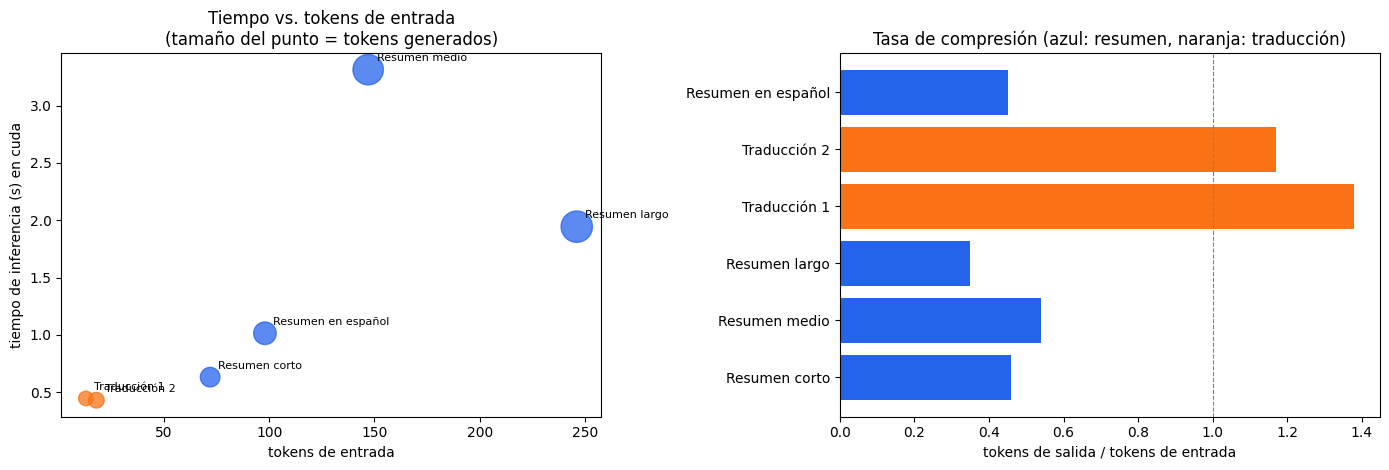

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))

colores_tarea = ["#2563eb" if "Resumen" in p else "#f97316" for p in tabla_resultados["prueba"]]
ax1.scatter(tabla_resultados["tokens entrada"], tabla_resultados["tiempo (s)"],
            s=tabla_resultados["tokens salida"] * 6, c=colores_tarea, alpha=0.75)
for _, fila in tabla_resultados.iterrows():
    ax1.annotate(fila["prueba"], (fila["tokens entrada"], fila["tiempo (s)"]),
                 textcoords="offset points", xytext=(6, 6), fontsize=8)
ax1.set_xlabel("tokens de entrada")
ax1.set_ylabel(f"tiempo de inferencia (s) en {dispositivo.type}")
ax1.set_title("Tiempo vs. tokens de entrada\n(tamaño del punto = tokens generados)")

ax2.barh(tabla_resultados["prueba"], tabla_resultados["compresión (salida/entrada)"], color=colores_tarea)
ax2.axvline(1, color="gray", ls="--", lw=0.8)
ax2.set_xlabel("tokens de salida / tokens de entrada")
ax2.set_title("Tasa de compresión (azul: resumen, naranja: traducción)")
guardar_figura("pruebas_inferencia")

**Cómo leer la tabla.** Para cada prueba están los tokens de entrada (con el prefijo incluido), los tokens que generó el modelo (sin contar el `<pad>` inicial, que no lo genera él, pero sí el `</s>` final), el tiempo, la tasa de compresión y la predicción completa.

**Gráfica izquierda, tiempo contra tokens de entrada.** Las dos traducciones son las más rápidas (0,43 y 0,45 s) porque generan pocos tokens, y el resumen corto, con 33 tokens generados, tardó 0,63 s. Eso confirma que lo que más pesa es la cantidad de tokens que se generan: el encoder procesa toda la entrada en paralelo, pero el decoder corre una vez por cada token (y con 4 haces).

Hubo un resultado que no esperábamos: el resumen medio (147 tokens de entrada, 80 generados) tardó 3,31 s, más que el largo (246 de entrada, 85 generados), que tardó 1,94 s. Por los tokens generados deberían haber tardado casi lo mismo. Lo más probable es que sea variación de la medición: era la primera vez que el modelo procesaba una entrada de ese tamaño, la GPU de Colab tiene que reservar memoria nueva y además es compartida con otros usuarios. Con una sola medición por prueba no se puede descartar ese ruido; para un análisis de tiempos serio habría que repetir cada prueba varias veces y tomar la mediana.

**Gráfica derecha, compresión.** Los resúmenes quedaron entre 0,35 y 0,54 de la entrada. En las traducciones pasa lo contrario, 1,38 y 1,17, porque el alemán necesitó más tokens que el inglés: solo *Künstliche* son cinco piezas.

**Qué notamos en los resúmenes.** Son muy *extractivos*: casi todas las frases están copiadas del texto original. El resumen corto es literalmente la primera oración más la segunda recortada, y el largo copia casi textuales las tres primeras oraciones del artículo. También se ven detalles propios de T5-small: casi todo sale en minúscula y en el resumen medio escribió *laguajira* pegado.

**Qué notamos en las traducciones.** La primera es perfecta. La segunda, *"Am Donnerstag präsentierten die Studenten ihr letztes Projekt über Transformatoren"*, es gramaticalmente correcta y hasta movió "el jueves" al inicio como se hace en alemán, pero tiene dos errores de significado muy interesantes. *Final project* lo tradujo como *letztes Projekt* ("último proyecto") en vez de *Abschlussprojekt*. Y *transformers* lo tradujo como *Transformatoren*, que en alemán son los transformadores eléctricos. Es el mismo problema de ambigüedad de *bank*: el modelo no sabía que hablábamos de redes neuronales, porque nada en la frase lo indica.

**La prueba en español.** La dejamos a propósito. Devolvió *"inteligencia artificial transformando muchas industrias al automatizar tareas repetitivas..."*: copió la primera oración, se comió el verbo *está* y descartó toda la segunda oración. T5-small no fue entrenado para resumir en español, así que es una limitación del modelo y no un error del código, y conecta con lo que vimos en la tokenización (18 tokens contra 7 en inglés).

## 12. Métricas de calidad

Las pruebas anteriores muestran que el modelo funciona, pero no dicen qué tan bien. Para eso comparamos sus salidas con referencias escritas por personas:

- **ROUGE** (para resumen): mide cuántas palabras (ROUGE-1), pares de palabras seguidas (ROUGE-2) y qué tan larga es la subsecuencia común más larga (ROUGE-L) que comparte el resumen generado con el de referencia. Va de 0 a 100.
- **BLEU** (para traducción): mide la coincidencia de grupos de 1 a 4 palabras, con una penalización si la traducción sale demasiado corta. **chrF** hace algo parecido pero a nivel de caracteres, y es más justo con idiomas como el alemán, que pega varias palabras en una sola.

Usamos 20 ejemplos del conjunto de prueba de CNN/DailyMail y 20 de WMT14 inglés-alemán, que son los mismos datasets del paper. Los cargamos en modo *streaming* para no descargar los datasets completos. Son pocos ejemplos: alcanzan para tener una idea del desempeño en el tiempo de la sustentación, pero no para comparar con decimales contra el paper.

In [21]:
from datasets import load_dataset
from rouge_score import rouge_scorer
import sacrebleu

N_EJEMPLOS = 20

try:
    cnn = load_dataset("abisee/cnn_dailymail", "3.0.0", split="test", streaming=True)
    ejemplos_cnn = list(cnn.take(N_EJEMPLOS))
except Exception as error:
    ejemplos_cnn = []
    print("No se pudo descargar CNN/DailyMail:", error)

evaluador = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
filas_rouge = []
for i, ejemplo in enumerate(ejemplos_cnn):
    r = predecir_t5(ejemplo["article"], tarea="summarize", max_tokens_salida=100)
    puntaje = evaluador.score(ejemplo["highlights"], r["prediccion"])   # (referencia, predicción)
    filas_rouge.append({
        "ejemplo": i,
        "ROUGE-1": 100 * puntaje["rouge1"].fmeasure,
        "ROUGE-2": 100 * puntaje["rouge2"].fmeasure,
        "ROUGE-L": 100 * puntaje["rougeL"].fmeasure,
        "segundos": r["segundos"],
        "prediccion": r["prediccion"],
        "referencia": ejemplo["highlights"],
    })

tabla_rouge = pd.DataFrame(filas_rouge)
if len(tabla_rouge):
    promedios_rouge = tabla_rouge[["ROUGE-1", "ROUGE-2", "ROUGE-L"]].agg(["mean", "std"]).round(2)
    display(promedios_rouge)

README.md: 0.00B [00:00, ?B/s]

,ROUGE-1,ROUGE-2,ROUGE-L
mean,33.88,13.40,24.17
std,13.18,9.73,11.21


In [22]:
try:
    wmt = load_dataset("wmt/wmt14", "de-en", split="test", streaming=True)
    ejemplos_wmt = list(wmt.take(N_EJEMPLOS))
except Exception as error:
    ejemplos_wmt = []
    print("No se pudo descargar WMT14:", error)

traducciones, referencias, filas_bleu = [], [], []
for ejemplo in ejemplos_wmt:
    origen, referencia = ejemplo["translation"]["en"], ejemplo["translation"]["de"]
    r = predecir_t5(origen, tarea="translate English to German", max_tokens_salida=120)
    traducciones.append(r["prediccion"])
    referencias.append(referencia)
    filas_bleu.append({"inglés": origen, "referencia": referencia, "T5-small": r["prediccion"],
                       "BLEU de la frase": round(sacrebleu.sentence_bleu(r["prediccion"], [referencia]).score, 1)})

tabla_bleu = pd.DataFrame(filas_bleu)
if traducciones:
    bleu = sacrebleu.corpus_bleu(traducciones, [referencias]).score
    chrf = sacrebleu.corpus_chrf(traducciones, [referencias]).score
    print(f"BLEU (corpus, {len(traducciones)} frases): {bleu:.2f}")
    print(f"chrF (corpus, {len(traducciones)} frases): {chrf:.2f}")
    display(tabla_bleu.head(5))

README.md: 0.00B [00:00, ?B/s]

BLEU (corpus, 20 frases): 18.31
chrF (corpus, 20 frases): 54.87


,inglés,referencia,T5-small,BLEU de la frase
0,Gutach: Increased safety for pedestrians,Gutach: Noch mehr Sicherheit für Fußgänger,Gutach: Erhöhte Sicherheit für Fußgänger,32.2
1,"They are not even 100 metres apart: On Tuesday, the new B 33 pedestrian lights in Dorfparkplatz in Gutach became operational - within view of the existing Town Hall traffic lights.",Sie stehen keine 100 Meter voneinander entfernt: Am Dienstag ist in Gutach die neue B 33-Fußgängerampel am Dorfparkplatz in Betrieb genommen worden - in Sichtweite der älteren Rathausampel.,Sie sind nicht einmal 100 m voneinander entfernt: Am Dienstag wurde die neue Fußgängerlampe B 33 im Dorfparkplatz in Gutach betrieben - mit Blick auf die bestehende Rathausampel.,18.1
2,Two sets of lights so close to one another: intentional or just a silly error?,Zwei Anlagen so nah beieinander: Absicht oder Schildbürgerstreich?,"Zwei Sets von Lichtern, die so nahe aneinander liegen: absichtlich oder einfach ein dummer Fehler?",3.2
3,"Yesterday, Gutacht's Mayor gave a clear answer to this question.",Diese Frage hat Gutachs Bürgermeister gestern klar beantwortet.,Gestern hat der Bürgermeister von Gutacht eine klare Antwort auf diese Frage gegeben.,4.0
4,"""At the time, the Town Hall traffic lights were installed because this was a school route,"" explained Eckert yesterday.","""Die Rathausampel ist damals installiert worden, weil diese den Schulweg sichert"", erläuterte Eckert gestern.","""Zum damaligen Zeitpunkt wurden die Ampeln des Rathauses installiert, weil dies eine Schulroute war"", erklärte Eckert gestern.",10.1


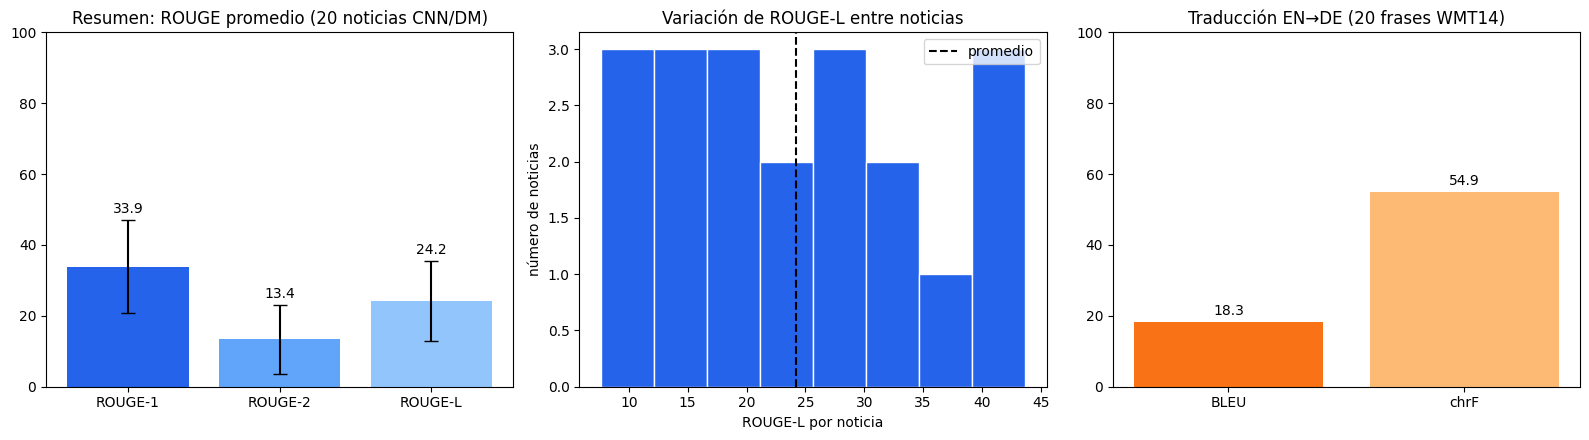

===== MEJOR ejemplo (ROUGE-L = 43.7) =====
Referencia: Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June . Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .
T5-small:   the palestinians signed the ICC's founding Rome Statute in January. it also accepted its jurisdiction over alleged crimes committed in occupied territories since June 13, 2014. a preliminary examination into the situation in Palestinian territories was opened in the hague on thursday, paving the way for possible war crimes investigations against Israelis. 

===== PEOR ejemplo (ROUGE-L = 7.6) =====
Referencia: LZ: Indiana law pushing back LGBT rights, and other states' anti-LGBT moves, bow to far right wing that GOP candidates need for 2016 . Cruz, Huckabee, Jindal, Carson, Walker are reviving culture wars, he says.  Equality for LGBT has not yet "won" in America .
T5-small:   a year ago, th

In [23]:
if len(tabla_rouge) and traducciones:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.5))

    medias = tabla_rouge[["ROUGE-1", "ROUGE-2", "ROUGE-L"]].mean()
    desv = tabla_rouge[["ROUGE-1", "ROUGE-2", "ROUGE-L"]].std()
    barras = ax1.bar(medias.index, medias.values, yerr=desv.values, capsize=5,
                     color=["#2563eb", "#60a5fa", "#93c5fd"])
    ax1.bar_label(barras, fmt="%.1f", padding=3)
    ax1.set_ylim(0, 100)
    ax1.set_title(f"Resumen: ROUGE promedio ({len(tabla_rouge)} noticias CNN/DM)")

    ax2.hist(tabla_rouge["ROUGE-L"], bins=8, color="#2563eb", edgecolor="white")
    ax2.axvline(tabla_rouge["ROUGE-L"].mean(), color="black", ls="--", label="promedio")
    ax2.set_xlabel("ROUGE-L por noticia")
    ax2.set_ylabel("número de noticias")
    ax2.set_title("Variación de ROUGE-L entre noticias")
    ax2.legend()

    barras = ax3.bar(["BLEU", "chrF"], [bleu, chrf], color=["#f97316", "#fdba74"])
    ax3.bar_label(barras, fmt="%.1f", padding=3)
    ax3.set_ylim(0, 100)
    ax3.set_title(f"Traducción EN→DE ({len(traducciones)} frases WMT14)")
    guardar_figura("metricas")

    mejor = tabla_rouge.loc[tabla_rouge["ROUGE-L"].idxmax()]
    peor = tabla_rouge.loc[tabla_rouge["ROUGE-L"].idxmin()]
    for etiqueta, fila in [("MEJOR", mejor), ("PEOR", peor)]:
        print(f"===== {etiqueta} ejemplo (ROUGE-L = {fila['ROUGE-L']:.1f}) =====")
        print("Referencia:", fila["referencia"].replace("\n", " "))
        print("T5-small:  ", fila["prediccion"], "\n")

**Lo que obtuvimos.**

| Tarea | Métrica | Resultado (20 ejemplos) | Referencia del paper (T5-Small) |
|---|---|---:|---:|
| Resumen (CNN/DailyMail) | ROUGE-1 | 33,9 ± 13,2 | |
| | ROUGE-2 | 13,4 ± 9,7 | ~19–20 |
| | ROUGE-L | 24,2 ± 11,2 | |
| Traducción (WMT14 EN→DE) | BLEU | 18,3 | ~26–27 |
| | chrF | 54,9 | |

**Cómo leer la gráfica de barras.** ROUGE-2 sale mucho más bajo que ROUGE-1 porque es más difícil acertar pares exactos de palabras seguidas que palabras sueltas, y ROUGE-L queda en medio. Las barras de error son la desviación estándar entre noticias, y son enormes: en ROUGE-2 la desviación (9,7) es casi tan grande como el promedio (13,4).

**El histograma** muestra justamente esa variación: a algunas noticias les va bastante bien y a otras muy mal. El mejor ejemplo (ROUGE-L 43,7) es la noticia de Palestina y la Corte Penal Internacional, donde el modelo escogió los mismos hechos que la referencia: la jurisdicción sobre crímenes en territorios palestinos y la posible investigación contra israelíes. El peor (ROUGE-L 7,6) es una columna de opinión: la referencia resume el argumento del autor (las leyes anti-LGBT y los candidatos republicanos), y el modelo copió frases sueltas de la mitad del texto sobre Pence y los hermanos Koch. No es un resumen inventado, pero escogió otra parte como "lo importante". Ahí está la debilidad de T5-small en resumen: le va bien con noticias donde lo importante está al principio y mal con textos de opinión.

**¿Por qué quedamos por debajo del paper?** Creemos que hay cuatro razones:

1. **La muestra.** Con 20 ejemplos y esa desviación, el promedio puede moverse varios puntos. El paper evalúa con el conjunto de prueba completo (más de 11.000 noticias en CNN/DM y 3.003 frases en WMT14).
2. **`no_repeat_ngram_size=2`.** Lo pusimos para que la app no repitiera frases, pero prohíbe repetir cualquier par de palabras dentro del resumen, incluso pares comunes como *of the* o un nombre propio de dos palabras. En un resumen de tres oraciones eso obliga al modelo a cambiar palabras que la referencia sí repite, y eso baja ROUGE-2 directamente.
3. **Los parámetros de generación.** El paper usa sus propios ajustes de longitud y penalización; nosotros fijamos un máximo de 100 tokens.
4. **Las frases de WMT.** Las primeras 20 frases del conjunto de prueba son todas de una misma noticia local alemana, con nombres propios y expresiones difíciles.

**BLEU contra chrF.** La diferencia entre los dos (18,3 contra 54,9) muestra el problema de BLEU. En la frase *"Yesterday, Gutacht's Mayor gave a clear answer to this question"*, el modelo escribió *"Gestern hat der Bürgermeister von Gutacht eine klare Antwort auf diese Frage gegeben"*, que es una traducción correcta, y sacó un BLEU de 4,0 solo porque la referencia usó otra construcción (*"Diese Frage hat Gutachs Bürgermeister gestern klar beantwortet"*). chrF, que compara por caracteres, reconoce mejor esas coincidencias parciales y las palabras compuestas del alemán. También hay errores reales: tradujo *pedestrian lights* (semáforo peatonal) como *Fußgängerlampe* ("lámpara de peatones") y *two sets of lights* de forma muy literal.

En resumen, las métricas confirman lo que vimos a mano: T5-small traduce frases sencillas bastante bien, y en resumen funciona sobre todo copiando las oraciones más importantes, con resultados muy desiguales según el tipo de texto.

## 13. Verificación automática

Estas comprobaciones confirman que cargamos la configuración esperada, que la atención reconstruida a mano coincide con la del modelo y que la máscara del decoder funciona.

In [24]:
assert modelo.config.is_encoder_decoder, "El modelo debe ser encoder-decoder."
assert modelo.config.d_model == 512, "La dimensión esperada para T5-small es 512."
assert modelo.config.num_layers == 6, "T5-small debe tener 6 capas de encoder."
assert modelo.config.num_decoder_layers == 6, "T5-small debe tener 6 capas de decoder."
assert diferencia < 1e-4, "La atención calculada a mano no coincide con la del modelo."
assert encima_diagonal < 1e-6, "La máscara del decoder no está bloqueando el futuro."
assert all(r["predicción"] for r in resultados), "Alguna predicción salió vacía."

print("✓ Arquitectura encoder-decoder y configuración de T5-small verificadas.")
print("✓ softmax(Q·Kᵀ + B)·V calculado a mano coincide con el modelo.")
print("✓ La autoatención del decoder no mira tokens futuros.")
print("✓ Todas las pruebas generaron una salida.")

✓ Arquitectura encoder-decoder y configuración de T5-small verificadas.
✓ softmax(Q·Kᵀ + B)·V calculado a mano coincide con el modelo.
✓ La autoatención del decoder no mira tokens futuros.
✓ Todas las pruebas generaron una salida.


## 14. ¿Qué tiene de innovador T5?

Lo dividimos en dos: lo que cambia en la arquitectura y lo que cambia en la forma de usarla.

| Aspecto | Transformer original (2017) | T5 (2020) |
|---|---|---|
| Posición | codificación sinusoidal absoluta, sumada al embedding | sesgo relativo aprendido (32 cajones) dentro de la atención, compartido por todos los bloques |
| Escalado de la atención | divide por $\sqrt{d_k}$ | no divide; se compensa en la inicialización |
| Normalización | LayerNorm después de cada subcapa | RMSNorm (sin media ni bias) antes de cada subcapa |
| Bias en las capas lineales | sí | no |
| Preentrenamiento | no tenía, se entrenaba para una tarea | *span corruption* sobre C4 (~750 GB de texto) |
| Formato de las tareas | un modelo por tarea | todo es texto a texto y la tarea se indica con un prefijo |

Para nosotros lo más innovador es la última fila. El paper hizo un estudio enorme comparando arquitecturas, objetivos de preentrenamiento, tamaños de datos y estrategias de ajuste, todo bajo el mismo formato, y eso solo fue posible porque cualquier tarea se podía escribir como texto. En el proyecto lo vimos en directo: cambiamos `summarize:` por `translate English to German:` y el mismo modelo, sin tocar una línea de la arquitectura, hizo otra tarea.

También entendimos por qué escogieron un encoder-decoder y no solo un decoder como GPT: el encoder puede mirar la entrada completa en las dos direcciones antes de que el decoder empiece a escribir, y en las comparaciones del paper esa combinación fue la que mejor funcionó.

## 15. Limitaciones

- **Idioma.** El vocabulario y el preentrenamiento son casi todo en inglés. Lo vimos en la tokenización (el español se parte en más pedazos) y en la prueba de resumen en español.
- **Longitud.** Truncamos la entrada en 512 tokens porque así se entrenó, y una noticia larga pierde el final. Además, como la tabla de atención es de $n \times n$, alargar mucho la entrada dispara la memoria.
- **Tamaño.** Con 60 millones de parámetros los resúmenes son muy extractivos: copia frases en vez de reescribirlas, y en textos de opinión escoge mal qué es lo importante (ROUGE-L de 7,6 en el peor caso). Las versiones grandes del paper son claramente mejores.
- **Ambigüedad sin contexto.** Si la frase no da pistas, escoge el sentido más común: tradujo *transformers* como transformadores eléctricos y *final project* como "último proyecto".
- **Tareas fijas.** Solo responde bien a los prefijos con los que se entrenó. Una instrucción libre como "explain this text:" no la entiende. Para una tarea nueva habría que hacer fine-tuning.
- **Métricas.** ROUGE y BLEU cuentan palabras coincidentes y no entienden el significado, y nuestra muestra de 20 ejemplos es pequeña. Además, el `no_repeat_ngram_size=2` que usamos en la app castiga el ROUGE.
- **Interpretación de la atención.** Los mapas muestran a dónde mira el modelo, pero no son una explicación completa de por qué produce una salida.
- **Puede inventar.** Como cualquier modelo generativo, puede escribir cosas que no estaban en el texto original.

## 16. Conclusiones

Al empezar el proyecto teníamos claro qué era la atención en el papel, pero calcularla a mano con las matrices del modelo fue lo que de verdad nos la aclaró. Cuando nuestro $\text{softmax}(QK^\top + B)V$ dio exactamente lo mismo que el modelo, con diferencia cero, entendimos que no hay nada mágico: Q, K y V son tres proyecciones lineales de los mismos vectores, y la atención es una forma de decidir, con porcentajes, cuánto toma cada token de los demás. De paso descubrimos dos detalles que no esperábamos, que T5 no divide por $\sqrt{d_k}$ y que la posición no se suma al embedding sino que entra como un sesgo dentro de la atención.

Lo segundo que aprendimos es por qué el Transformer reemplazó a las RNN y LSTM que vimos en clase. En una RNN todo el pasado tiene que pasar por $h(t)$; en T5 cada token del decoder consulta directamente la memoria del encoder. Lo vimos en la atención cruzada de la traducción, donde cada palabra en alemán buscaba su pareja en inglés aunque el orden de la frase cambiara, y en la máscara del decoder, que conserva la idea de "no mirar el futuro" de las redes recurrentes pero sin el cuello de botella. Ver que cada pedazo de *Künstliche* apuntaba a *Artificial* y que *unterstützen* encontraba a *support* al otro lado de la frase fue de lo más claro del proyecto. El ejemplo de *bank* nos mostró además que el significado no está en el embedding sino en el contexto: entra el mismo vector en las tres frases y sale con los dos sentidos de dinero juntos (0,67) y el del río aparte. Y nos dejó una lección que no esperábamos: *bank* casi no le pone atención directa a *river*, así que los mapas de atención ayudan a entender, pero no cuentan toda la historia.

Sobre T5 en particular, nos quedamos con que su aporte más grande no fue una capa nueva sino la idea de escribir todo como texto a texto. Con eso un solo modelo resume y traduce cambiando unas palabras al inicio. Los cambios de arquitectura (sesgo relativo, RMSNorm antes de cada subcapa, quitar el $\sqrt{d_k}$ y los bias) son pequeños, pero hacen el modelo más simple y estable.

En cuanto a los resultados, T5-small responde en menos de medio segundo en traducciones y entre 0,6 y 3,3 segundos en resúmenes con GPU. En métricas obtuvimos 13,4 de ROUGE-2 y 18,3 de BLEU, por debajo de lo que reporta el paper, y creemos que se explica por la muestra pequeña, los parámetros de generación que escogimos para la app y el tipo de frases. También encontramos sus límites con claridad: casi no sirve en español, se confunde con palabras ambiguas como *transformers*, trunca textos largos y sus resúmenes copian más de lo que reescriben.

Si siguiéramos con el proyecto, haríamos fine-tuning con textos en español o probaríamos mT5 (la versión multilingüe), evaluaríamos con más ejemplos (y sin el `no_repeat_ngram_size=2`, para medir cuánto afecta) y compararíamos con T5-base para ver cuánto mejora el resumen con un modelo más grande.

## Referencias

[1] C. Raffel, N. Shazeer, A. Roberts, K. Lee, S. Narang, M. Matena, Y. Zhou, W. Li y P. J. Liu, "Exploring the limits of transfer learning with a unified text-to-text transformer," *J. Mach. Learn. Res.*, vol. 21, no. 140, pp. 1–67, 2020.

[2] A. Vaswani *et al.*, "Attention is all you need," en *Proc. Adv. Neural Inf. Process. Syst. (NeurIPS)*, 2017, pp. 5998–6008.

[3] D. Bahdanau, K. Cho y Y. Bengio, "Neural machine translation by jointly learning to align and translate," en *Proc. Int. Conf. Learn. Represent. (ICLR)*, 2015.

[4] S. Hochreiter y J. Schmidhuber, "Long short-term memory," *Neural Comput.*, vol. 9, no. 8, pp. 1735–1780, 1997.

[5] P. Shaw, J. Uszkoreit y A. Vaswani, "Self-attention with relative position representations," en *Proc. NAACL-HLT*, 2018, pp. 464–468.

[6] B. Zhang y R. Sennrich, "Root mean square layer normalization," en *Proc. Adv. Neural Inf. Process. Syst. (NeurIPS)*, 2019.

[7] T. Kudo y J. Richardson, "SentencePiece: A simple and language independent subword tokenizer and detokenizer for neural text processing," en *Proc. EMNLP: System Demonstrations*, 2018, pp. 66–71.

[8] F. Chollet, *Deep Learning with Python*, 2.ª ed. Shelter Island, NY, EE. UU.: Manning, 2021.

[9] C.-Y. Lin, "ROUGE: A package for automatic evaluation of summaries," en *Text Summarization Branches Out*, 2004, pp. 74–81.

[10] K. Papineni, S. Roukos, T. Ward y W.-J. Zhu, "BLEU: A method for automatic evaluation of machine translation," en *Proc. ACL*, 2002, pp. 311–318.

[11] M. Post, "A call for clarity in reporting BLEU scores," en *Proc. Conf. Mach. Transl. (WMT)*, 2018, pp. 186–191.

[12] Hugging Face, "T5," *Transformers Documentation*. [En línea]. Disponible: https://huggingface.co/docs/transformers/model_doc/t5

[13] Google Research, "T5: Text-To-Text Transfer Transformer," *GitHub*. [En línea]. Disponible: https://github.com/google-research/text-to-text-transfer-transformer